# Machine Learning Pipeline - Price Classification
## Random Forest Classifier untuk Estimasi Kategori Harga Bengkel Las

**Tujuan**: Mengklasifikasikan harga jasa bengkel las ke dalam 3 kategori: **Rendah**, **Sedang**, **Tinggi**

**Workflow**:
1. Load & Exploratory Data Analysis (EDA)
2. Feature Engineering & Preprocessing
3. Label Creation (berdasarkan distribusi harga)
4. Handle Imbalanced Data
5. Model Training (Random Forest Classifier)
6. Model Evaluation
7. Save Model & Price Ranges


---
## 1. Import Libraries


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Model saving
import joblib
import json
import io
from google.colab import files

import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


---
## 2. Load Dataset


In [ ]:
# Load dataset (UPLOAD CSV di Colab)
uploaded = files.upload()
filename = next(iter(uploaded.keys()))

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"📊 Dataset Shape: {df.shape}")
print(f"📊 Jumlah Data: {len(df)} baris, {df.shape[1]} kolom\n")

# Display first rows
df.head()


Saving azkaljayalas_dataset.csv to azkaljayalas_dataset (1).csv
📊 Dataset Shape: (600, 20)
📊 Jumlah Data: 600 baris, 20 kolom



,order_id,tanggal,tahun,pelanggan,lokasi,produk,jenis_material,profile_size,ketebalan_material,ukuran,jumlah_unit,jumlah_lubang,metode_hitung,harga_per_m2,harga_per_m,harga_per_lubang,upah_tenaga_ahli,finishing,kerumitan_desain,harga_final
0,ORD-00001,3/29/2020,2020,Sukirman Wicaksono,Suradadi,Pintu Handerson,Hollow,4x4,0.8,4.73,1,0,PER-M2,800000,0,0,473000,Cat Biasa,Sederhana,3850000
1,ORD-00002,7/24/2024,2024,Bu Marni Sulastri,Balapulang,Railing,Hollow,4x4,0.8,2.70,3,0,PER-M,0,500000,0,810000,Cat Biasa,Kompleks,4250000
2,ORD-00003,3/19/2021,2021,Pak Darsono Hidayat,Margasari,Pagar,Hollow Stainless,4x8,1.2,12.80,1,0,PER-M2,1200000,0,0,1920000,Tanpa Cat,Sederhana,15350000
3,ORD-00004,8/22/2023,2023,Lilis Mariyam,Slawi,Pintu Gerbang,Hollow Stainless,4x4,0.8,6.00,1,0,PER-M2,1300000,0,0,900000,Tanpa Cat,Kompleks,7950000
4,ORD-00005,12/10/2021,2021,Dimas Ramadhan,Tegal,Pintu Handerson,Hollow,4x8,1.2,2.70,2,0,PER-M2,1000000,0,0,540000,Cat Biasa,Menengah,5550000


---
## 3. Exploratory Data Analysis (EDA)


### 3.1 Dataset Info & Missing Values


In [ ]:
# Dataset info
print("📋 Dataset Info:")
print(df.info())
print("\n" + "="*80 + "\n")

# Missing values
print("🔍 Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("✅ No missing values found!")


📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            600 non-null    object 
 1   tanggal             600 non-null    object 
 2   tahun               600 non-null    int64  
 3   pelanggan           600 non-null    object 
 4   lokasi              600 non-null    object 
 5   produk              600 non-null    object 
 6   jenis_material      600 non-null    object 
 7   profile_size        600 non-null    object 
 8   ketebalan_material  600 non-null    float64
 9   ukuran              600 non-null    float64
 10  jumlah_unit         600 non-null    int64  
 11  jumlah_lubang       600 non-null    int64  
 12  metode_hitung       600 non-null    object 
 13  harga_per_m2        600 non-null    int64  
 14  harga_per_m         600 non-null    int64  
 15  harga_per_lubang    600 non-null    int64

### 3.1.1 Data Quality Checks (Duplicates, Types, Basic Validity)


In [ ]:
print("="*80)
print("🧼 DATA QUALITY CHECKS")
print("="*80)

# Duplicates (full row)
dup_rows = df.duplicated().sum()
print(f"Duplicate rows (full row): {dup_rows}")

# Duplicates by order_id if exists
if 'order_id' in df.columns:
    dup_order = df['order_id'].duplicated().sum()
    print(f"Duplicate order_id: {dup_order}")

# Basic numeric validity checks
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'harga_final' in df.columns:
    invalid_price = (df['harga_final'] <= 0).sum()
    print(f"Invalid harga_final (<=0): {invalid_price}")

# Check negative values in numeric cols
neg_counts = {}
for c in num_cols:
    neg_counts[c] = int((df[c] < 0).sum())
neg_df = pd.DataFrame({"neg_count": neg_counts}).sort_values("neg_count", ascending=False)
neg_df = neg_df[neg_df["neg_count"] > 0]
print("\nNegative values count (if any):")
print(neg_df if len(neg_df) else "✅ No negative values found in numeric columns.")

# Data types summary
print("\nDtypes summary:")
display(df.dtypes.value_counts())


🧼 DATA QUALITY CHECKS
Duplicate rows (full row): 0
Duplicate order_id: 0
Invalid harga_final (<=0): 0

Negative values count (if any):
✅ No negative values found in numeric columns.

Dtypes summary:


,count
object,10
int64,8
float64,2


### 3.2 Statistical Summary


### 3.2.1 Cardinality & Top Categories (Categorical Deep Dive)


In [ ]:
print("="*80)
print("🏷️ CATEGORICAL DEEP DIVE")
print("="*80)

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    vc = df[col].value_counts(dropna=False)
    print(f"\n[{col}] unique={df[col].nunique(dropna=False)}")
    display(vc.head(15).to_frame("count"))
    print(f"Coverage top-15: {(vc.head(15).sum()/len(df))*100:.2f}%")


🏷️ CATEGORICAL DEEP DIVE

[order_id] unique=600


,count
order_id,
ORD-00600,1
ORD-00001,1
ORD-00002,1
ORD-00003,1
ORD-00004,1
ORD-00005,1
ORD-00006,1
ORD-00007,1
ORD-00584,1


Coverage top-15: 2.50%

[tanggal] unique=530


,count
tanggal,
8/14/2023,3
1/17/2022,3
7/24/2024,2
9/12/2024,2
6/18/2023,2
12/18/2020,2
8/1/2020,2
1/13/2023,2
10/12/2024,2


Coverage top-15: 5.33%

[pelanggan] unique=487


...

Coverage top-15: 100.00%

[finishing] unique=4


,count
finishing,
Tanpa Cat,333
Cat Biasa,130
Cat Dasar,83
Cat Duco,54


Coverage top-15: 100.00%

[kerumitan_desain] unique=3


,count
kerumitan_desain,
Sederhana,291
Menengah,253
Kompleks,56


Coverage top-15: 100.00%


In [ ]:
# Deskripsi statistik numerik
print("📊 Statistical Summary - Numerical Features:")
df.describe().T


📊 Statistical Summary - Numerical Features:


,count,mean,std,min,25%,50%,75%,max
tahun,600.0,2.022078e+03,1.947267e+00,2019.0,2020.0,2022.0,2.024000e+03,2025.0
ketebalan_material,600.0,1.011000e+00,1.720319e-01,0.8,0.8,1.0,1.200000e+00,1.2
ukuran,600.0,8.908000e+00,7.315577e+00,0.0,3.0,7.4,1.367750e+01,30.0
jumlah_unit,600.0,1.373333e+00,7.290460e-01,1.0,1.0,1.0,2.000000e+00,7.0
jumlah_lubang,600.0,2.413333e+00,5.688564e+00,0.0,0.0,0.0,0.000000e+00,28.0
harga_per_m2,600.0,5.978333e+05,5.306518e+05,0.0,0.0,650000.0,9.625000e+05,1850000.0
harga_per_m,600.0,1.702000e+05,3.795894e+05,0.0,0.0,0.0,0.000000e+00,1350000.0
harga_per_lubang,600.0,1.142500e+05,2.573645e+05,0.0,0.0,0.0,0.000000e+00,900000.0
upah_tenaga_ahli,600.0,1.941509e+06,1.384982e+06,228000.0,954500.0,1600000.0,2.550000e+06,8876000.0
harga_final,600.0,1.161650e+07,7.360056e+06,1200000.0,6150000.0,10000000.0,1.492500e+07,46800000.0


In [ ]:
# Deskripsi statistik kategorikal
print("📊 Statistical Summary - Categorical Features:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")


📊 Statistical Summary - Categorical Features:

order_id:
order_id
ORD-00600    1
ORD-00001    1
ORD-00002    1
ORD-00003    1
ORD-00004    1
            ..
ORD-00013    1
ORD-00012    1
ORD-00011    1
ORD-00010    1
ORD-00009    1
Name: count, Length: 600, dtype: int64
Unique values: 600

tanggal:
tanggal
8/14/2023    3
1/17/2022    3
7/24/2024    2
9/12/2024    2
6/18/2023    2
            ..
9/29/2022    1
5/22/2019    1
3/13/2025    1
8/3/2024     1
1/18/2022    1
Name: count, Length: 530, dtype: int64
Unique values: 530

pelanggan:
pelanggan
Puskesmas Jatinegara    4
Meli Anjani             3
Mahendra Prakoso        3
Zidan Pramudya          3
Rendy Wicaksono         3
                       ..
TPQ Annur               1
Bu Ningsih              1
Konter HP Mandiri       1
Pak Karso Bengkel       1
Bu Wati                 1
Name: count, Length: 487, dtype: int64
Unique values: 487

lokasi:
lokasi
Slawi          100
Tegal           57
Bojong          46
Lebaksiu        42
Kramat      

### 3.3 Distribusi Harga Final (Target Variable)


### 3.3.1 Target Breakdown by Key Segments (metode_hitung, produk, kerumitan_desain)


💰 TARGET BREAKDOWN BY SEGMENTS

--- harga_final stats by metode_hitung ---


,count,min,median,mean,max,std
metode_hitung,,,,,,
PER-M2,380,1500000,10975000.0,1.211855e+07,39850000,7.078328e+06
PER-M,112,1200000,9475000.0,1.279688e+07,46800000,9.510628e+06
PER-LUBANG,108,1850000,7800000.0,8.625926e+06,21150000,4.535681e+06



--- harga_final stats by produk ---


,count,min,median,mean,max,std
produk,,,,,,
Railing,112,1200000,9475000.0,1.279688e+07,46800000,9.510628e+06
Teralis,108,1850000,7800000.0,8.625926e+06,21150000,4.535681e+06
Pagar,98,3450000,14300000.0,1.555561e+07,38400000,7.032076e+06
Pintu Handerson,95,2000000,6950000.0,7.821579e+06,19450000,4.289340e+06
Kanopi,94,1500000,12150000.0,1.455266e+07,39850000,7.816922e+06
Pintu Gerbang,93,3600000,8900000.0,1.042581e+07,36500000,5.752989e+06



--- harga_final stats by kerumitan_desain ---


,count,min,median,mean,max,std
kerumitan_desain,,,,,,
Sederhana,291,1200000,10000000.0,1.169897e+07,46800000,7.706599e+06
Menengah,253,1500000,9200000.0,1.110435e+07,43250000,7.057683e+06
Kompleks,56,2350000,12925000.0,1.350179e+07,32950000,6.612350e+06



--- harga_final stats by finishing ---


,count,min,median,mean,max,std
finishing,,,,,,
Tanpa Cat,333,1500000,12700000.0,1.413619e+07,46800000,8.172106e+06
Cat Biasa,130,1200000,7075000.0,8.189615e+06,24050000,4.657975e+06
Cat Dasar,83,2400000,8050000.0,8.823494e+06,23000000,4.725110e+06
Cat Duco,54,2500000,8350000.0,8.621296e+06,22050000,4.059982e+06



--- harga_final stats by jenis_material ---


,count,min,median,mean,max,std
jenis_material,,,,,,
Hollow,265,1200000,7500000.0,8.412075e+06,24050000,4.573253e+06
Pipa Stainless,174,2800000,11900000.0,1.352011e+07,46800000,7.700201e+06
Hollow Stainless,161,3000000,13600000.0,1.483354e+07,45000000,8.533401e+06


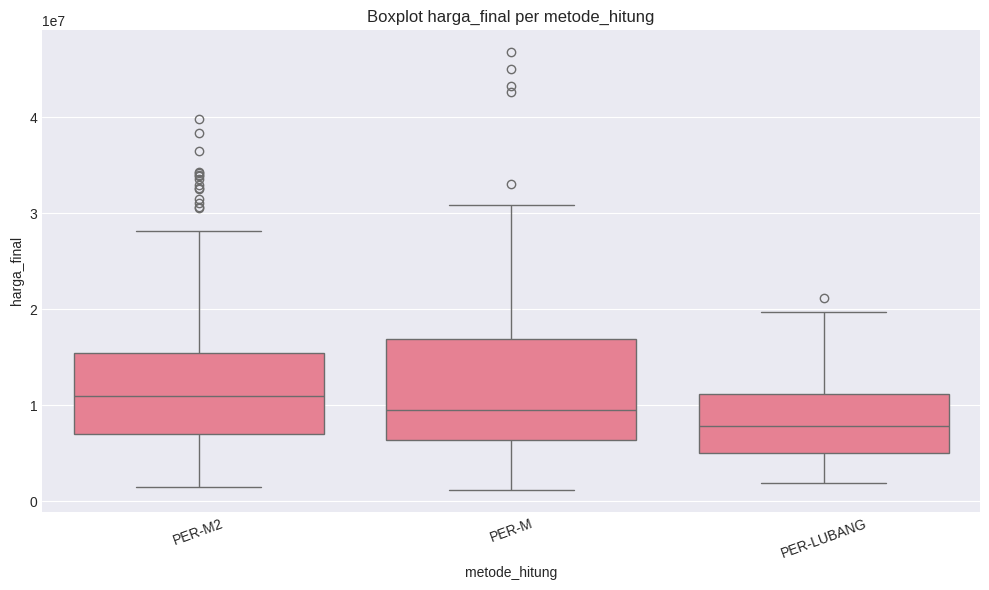

In [ ]:
print("="*80)
print("💰 TARGET BREAKDOWN BY SEGMENTS")
print("="*80)

def group_price_stats(group_col):
    g = df.groupby(group_col)['harga_final']
    out = g.agg(['count','min','median','mean','max','std']).sort_values('count', ascending=False)
    return out

for col in ['metode_hitung', 'produk', 'kerumitan_desain', 'finishing', 'jenis_material']:
    if col in df.columns:
        print(f"\n--- harga_final stats by {col} ---")
        display(group_price_stats(col).head(20))

# Visual: boxplot per metode_hitung (paling penting)
if 'metode_hitung' in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df, x='metode_hitung', y='harga_final')
    plt.title("Boxplot harga_final per metode_hitung")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


### 3.3.2 Quantile Reference (Baseline Only)
Catatan: Quantile di bawah ini hanya untuk referensi distribusi harga. Label final ditentukan secara data-driven menggunakan clustering pada Section 5.


In [ ]:
q = df['harga_final'].quantile([0, 1/3, 2/3, 1]).to_dict()
print("Quantile boundaries used for 3-class qcut (approx):")
for k, v in q.items():
    print(f"  q={k:.2f}: Rp {v:,.0f}")


Quantile boundaries used for 3-class qcut (approx):
  q=0.00: Rp 1,200,000
  q=0.33: Rp 7,683,333
  q=0.67: Rp 13,050,000
  q=1.00: Rp 46,800,000


💰 Distribusi Harga Final:
Min: Rp 1,200,000
Max: Rp 46,800,000
Mean: Rp 11,616,500
Median: Rp 10,000,000
Std Dev: Rp 7,360,056

📊 Quantiles (25%, 50%, 75%):
0.25     6150000.0
0.33     7567000.0
0.50    10000000.0
0.66    12800000.0
0.75    14925000.0
Name: harga_final, dtype: float64


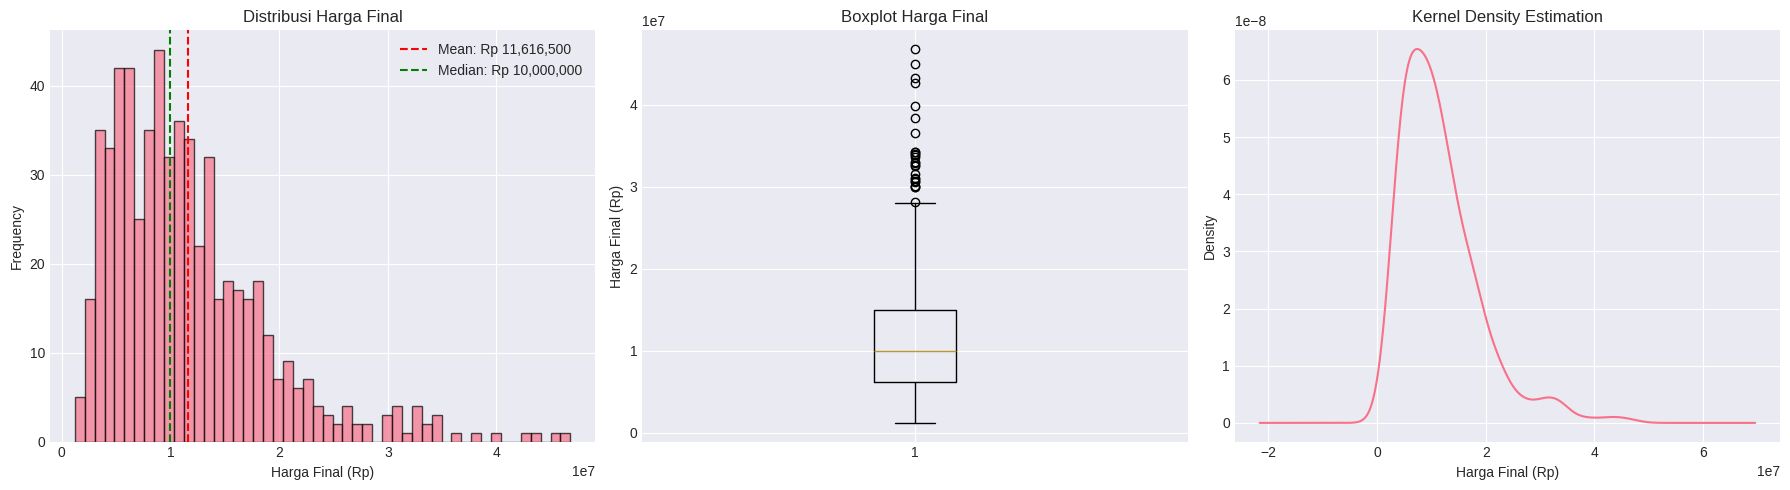

In [ ]:
# Analisis distribusi harga_final
print("💰 Distribusi Harga Final:")
print(f"Min: Rp {df['harga_final'].min():,.0f}")
print(f"Max: Rp {df['harga_final'].max():,.0f}")
print(f"Mean: Rp {df['harga_final'].mean():,.0f}")
print(f"Median: Rp {df['harga_final'].median():,.0f}")
print(f"Std Dev: Rp {df['harga_final'].std():,.0f}")

# Quantiles untuk menentukan kategori
print("\n📊 Quantiles (25%, 50%, 75%):")
quantiles = df['harga_final'].quantile([0.25, 0.33, 0.5, 0.66, 0.75])
print(quantiles)

# Visualisasi distribusi harga
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['harga_final'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Harga Final (Rp)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribusi Harga Final')
axes[0].axvline(df['harga_final'].mean(), color='red', linestyle='--', label=f'Mean: Rp {df["harga_final"].mean():,.0f}')
axes[0].axvline(df['harga_final'].median(), color='green', linestyle='--', label=f'Median: Rp {df["harga_final"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['harga_final'], vert=True)
axes[1].set_ylabel('Harga Final (Rp)')
axes[1].set_title('Boxplot Harga Final')

# KDE Plot
df['harga_final'].plot(kind='kde', ax=axes[2])
axes[2].set_xlabel('Harga Final (Rp)')
axes[2].set_title('Kernel Density Estimation')

plt.tight_layout()
plt.show()


### 3.4 Outlier Detection


In [ ]:
# Deteksi outlier menggunakan IQR method
Q1 = df['harga_final'].quantile(0.25)
Q3 = df['harga_final'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['harga_final'] < lower_bound) | (df['harga_final'] > upper_bound)]

print(f"🔍 Outlier Detection (IQR Method):")
print(f"Lower Bound: Rp {lower_bound:,.0f}")
print(f"Upper Bound: Rp {upper_bound:,.0f}")
print(f"Jumlah Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print("\nOutliers:")
    print(outliers[['order_id', 'produk', 'harga_final']].sort_values('harga_final', ascending=False))


🔍 Outlier Detection (IQR Method):
Lower Bound: Rp -7,012,500
Upper Bound: Rp 28,087,500
Jumlah Outliers: 25 (4.17%)

Outliers:
      order_id         produk  harga_final
334  ORD-00335        Railing     46800000
114  ORD-00115        Railing     45000000
77   ORD-00078        Railing     43250000
101  ORD-00102        Railing     42600000
38   ORD-00039         Kanopi     39850000
502  ORD-00503          Pagar     38400000
412  ORD-00413  Pintu Gerbang     36500000
232  ORD-00233          Pagar     34300000
381  ORD-00382          Pagar     34200000
487  ORD-00488          Pagar     34050000
395  ORD-00396  Pintu Gerbang     33900000
305  ORD-00306         Kanopi     33600000
489  ORD-00490        Railing     33050000
286  ORD-00287         Kanopi     32950000
299  ORD-00300         Kanopi     32600000
579  ORD-00580          Pagar     32500000
214  ORD-00215          Pagar     31500000
251  ORD-00252         Kanopi     31050000
298  ORD-00299        Railing     30900000
132  ORD-0013

### 3.5 Bivariate Analysis: Numeric Features vs harga_final (Scatter + Log-scale)


📈 BIVARIATE ANALYSIS (NUMERIC vs harga_final)


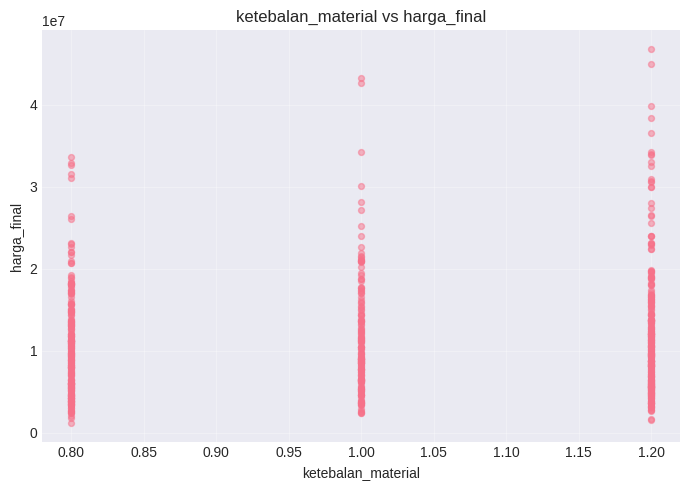

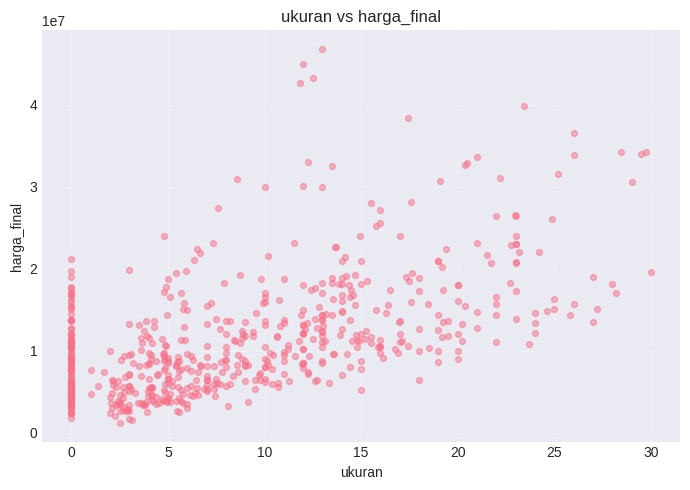

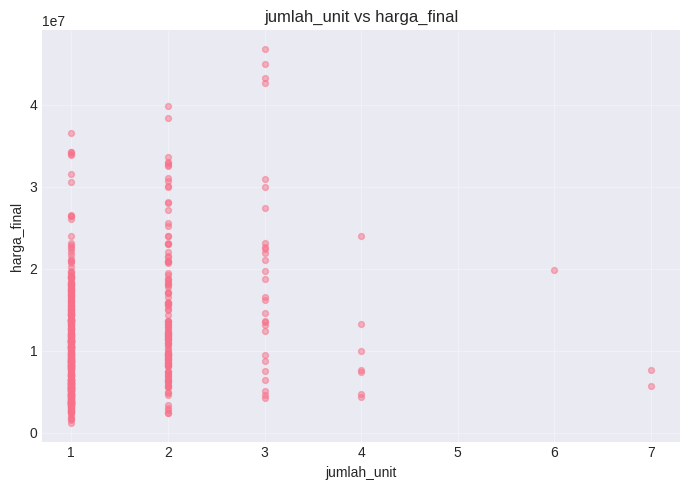

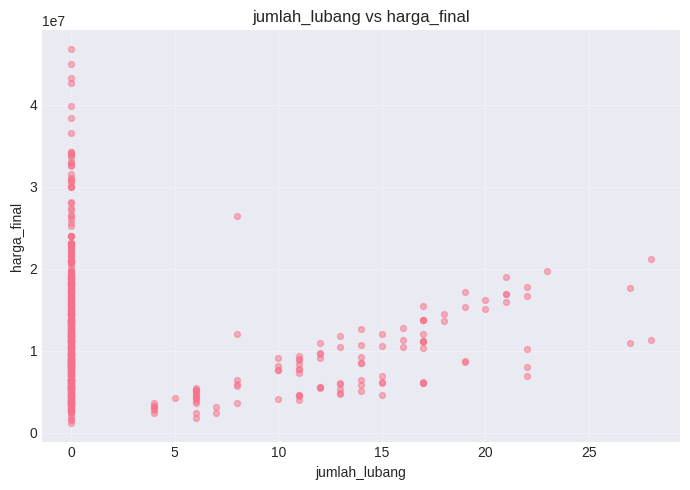

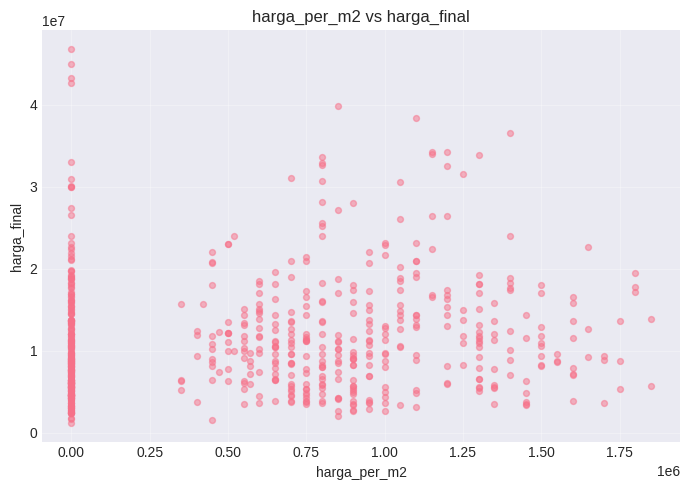

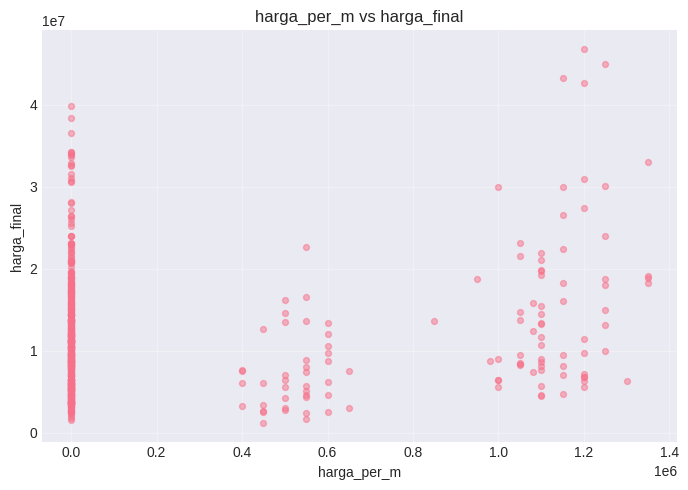

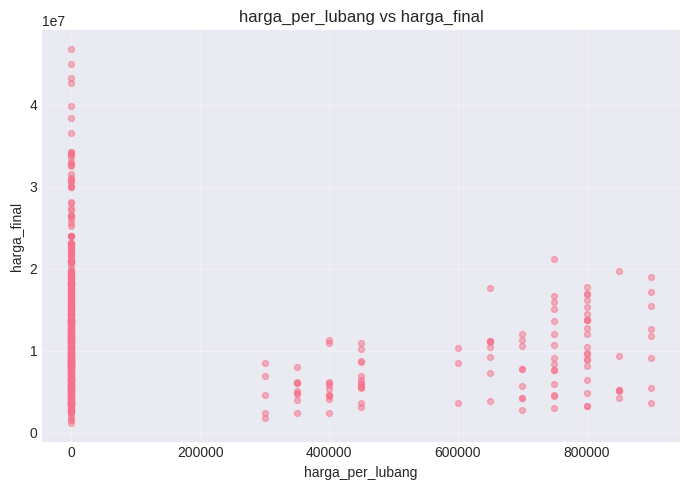

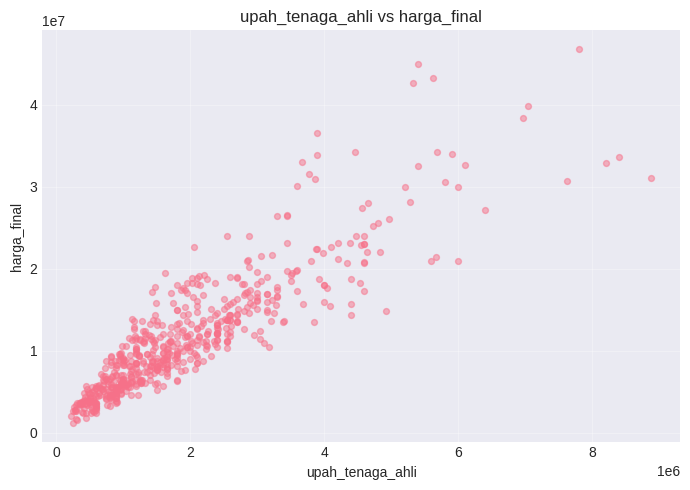

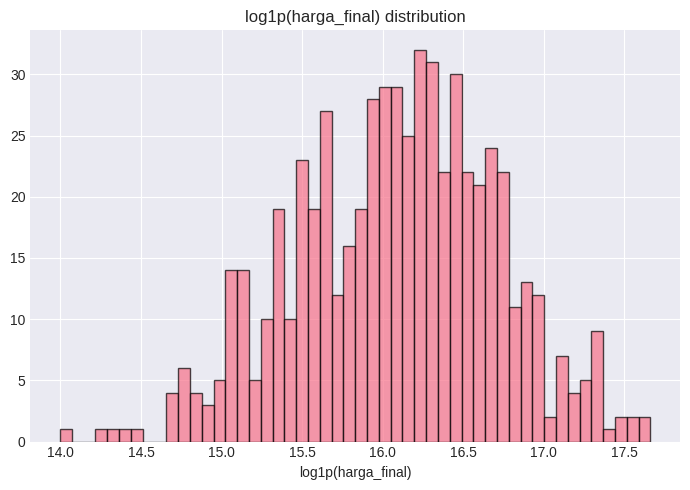

In [ ]:
print("="*80)
print("📈 BIVARIATE ANALYSIS (NUMERIC vs harga_final)")
print("="*80)

numeric_candidates = [
    'ketebalan_material','ukuran','jumlah_unit','jumlah_lubang',
    'harga_per_m2','harga_per_m','harga_per_lubang','upah_tenaga_ahli'
]
numeric_candidates = [c for c in numeric_candidates if c in df.columns]

for c in numeric_candidates:
    plt.figure(figsize=(7,5))
    plt.scatter(df[c], df['harga_final'], alpha=0.5, s=18)
    plt.xlabel(c)
    plt.ylabel("harga_final")
    plt.title(f"{c} vs harga_final")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Optional: log view for harga_final (helps when skewed)
plt.figure(figsize=(7,5))
plt.hist(np.log1p(df['harga_final']), bins=50, edgecolor='black', alpha=0.7)
plt.title("log1p(harga_final) distribution")
plt.xlabel("log1p(harga_final)")
plt.tight_layout()
plt.show()


### 3.6 Interaction EDA: metode_hitung × Rate Columns (Consistency Checks)


In [ ]:
print("="*80)
print("🧪 CONSISTENCY CHECK: metode_hitung vs rate columns")
print("="*80)

rate_cols = ['harga_per_m2','harga_per_m','harga_per_lubang']
rate_cols = [c for c in rate_cols if c in df.columns]

if 'metode_hitung' in df.columns and rate_cols:
    for m, sub in df.groupby(df['metode_hitung'].astype(str).str.upper()):
        print(f"\n[{m}] count={len(sub)}")
        for rc in rate_cols:
            zeros_pct = (sub[rc] == 0).mean() * 100
            nonzero_pct = (sub[rc] > 0).mean() * 100
            print(f"  {rc}: zeros={zeros_pct:.1f}% | nonzero={nonzero_pct:.1f}%")


🧪 CONSISTENCY CHECK: metode_hitung vs rate columns

[PER-LUBANG] count=108
  harga_per_m2: zeros=100.0% | nonzero=0.0%
  harga_per_m: zeros=100.0% | nonzero=0.0%
  harga_per_lubang: zeros=0.0% | nonzero=100.0%

[PER-M] count=112
  harga_per_m2: zeros=100.0% | nonzero=0.0%
  harga_per_m: zeros=0.0% | nonzero=100.0%
  harga_per_lubang: zeros=100.0% | nonzero=0.0%

[PER-M2] count=380
  harga_per_m2: zeros=0.0% | nonzero=100.0%
  harga_per_m: zeros=100.0% | nonzero=0.0%
  harga_per_lubang: zeros=100.0% | nonzero=0.0%


---
## 4. Feature Engineering & Preprocessing


### 4.1 Analyze Existing Features First


📊 Correlation with Target (harga_final):

harga_final           1.000000
upah_tenaga_ahli      0.889482
ukuran                0.574823
jumlah_unit           0.242478
harga_per_m           0.165283
harga_per_m2          0.108047
ketebalan_material    0.093062
tahun                 0.061827
jumlah_lubang        -0.079181
harga_per_lubang     -0.141681
Name: harga_final, dtype: float64



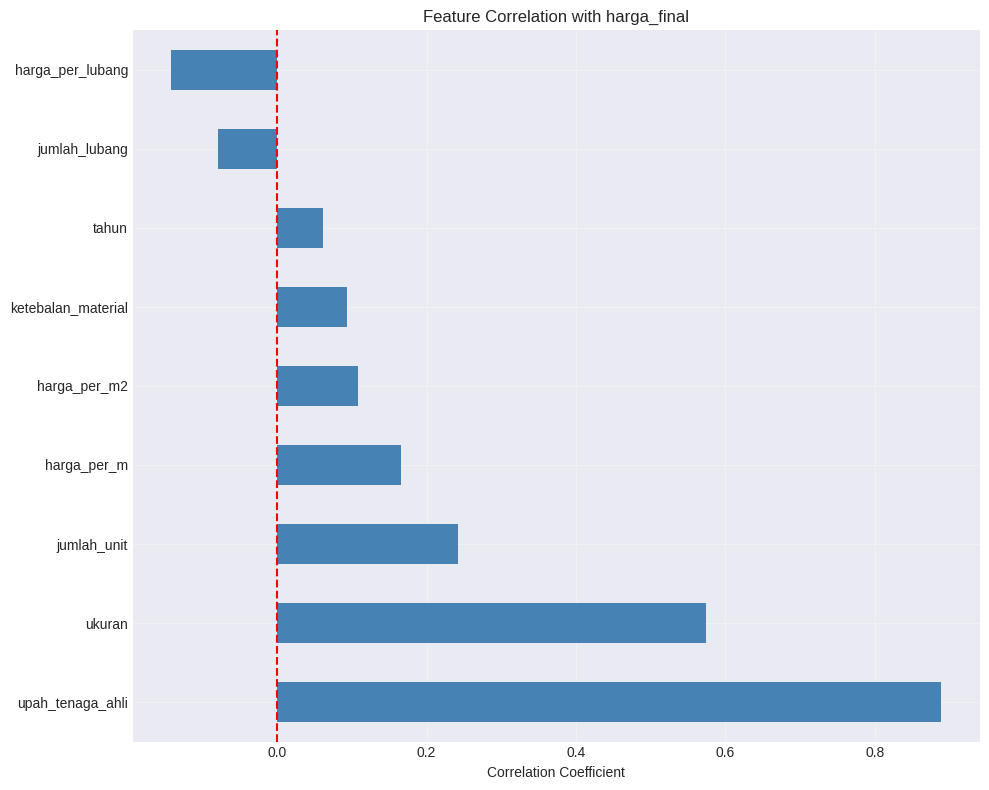


⚠️ Features with weak correlation (|r| < 0.1):
   - ketebalan_material: 0.0931
   - tahun: 0.0618
   - jumlah_lubang: -0.0792


In [ ]:
# Analisis korelasi features existing dengan harga_final
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'order_id' in numeric_cols:
    numeric_cols.remove('order_id')  # exclude ID

correlation_with_target = df[numeric_cols].corr()['harga_final'].sort_values(ascending=False)

print("📊 Correlation with Target (harga_final):\n")
print(correlation_with_target)
print("\n" + "="*80)

# Visualisasi correlation
plt.figure(figsize=(10, 8))
correlation_with_target.drop('harga_final').plot(kind='barh', color='steelblue')
plt.xlabel('Correlation Coefficient')
plt.title('Feature Correlation with harga_final')
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Identify features with low correlation (< 0.1)
weak_features = correlation_with_target[abs(correlation_with_target) < 0.1].index.tolist()
if 'harga_final' in weak_features:
    weak_features.remove('harga_final')

print(f"\n⚠️ Features with weak correlation (|r| < 0.1):")
for feat in weak_features:
    print(f"   - {feat}: {correlation_with_target[feat]:.4f}")


### 4.2 Feature Engineering Candidates Analysis


📊 Correlation Analysis - New Feature Candidates:

total_area                 0.727240
material_thickness_area    0.591860
is_per_m2                  0.089724
total_lubang              -0.080390
is_per_lubang             -0.190531
Name: harga_final, dtype: float64



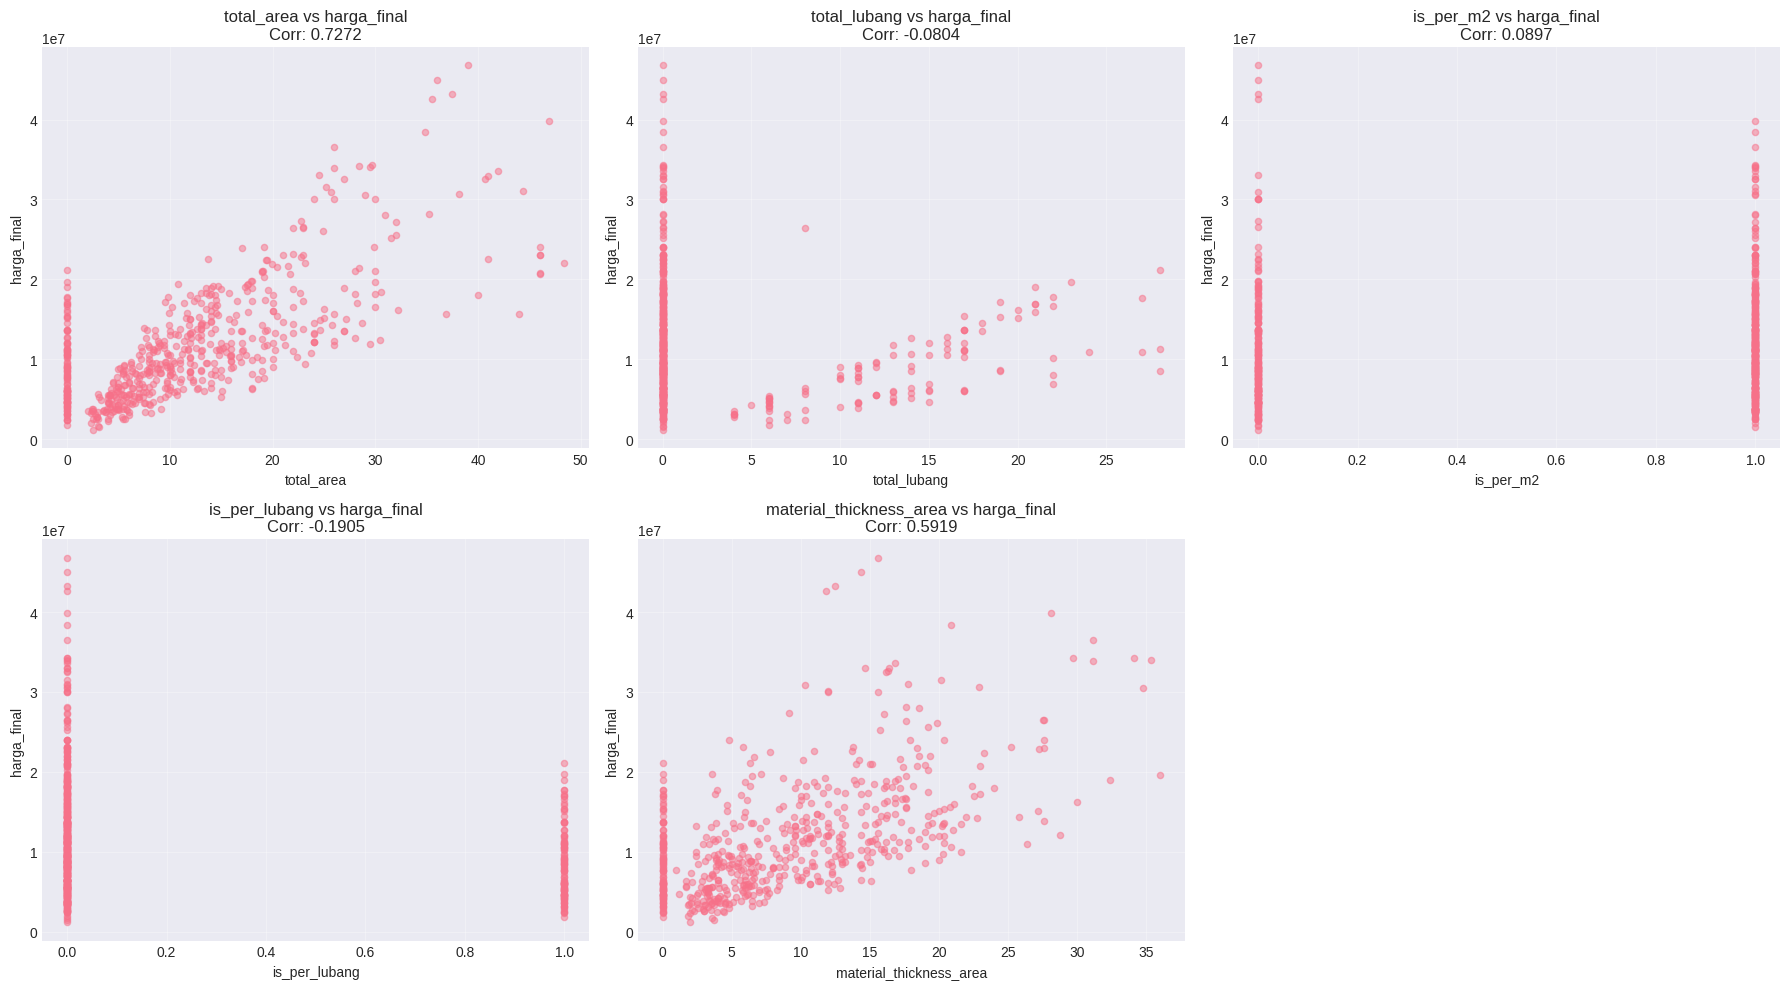


✅ Selected Features (|r| > 0.1):
   - total_area: r = 0.7272
   - is_per_lubang: r = -0.1905
   - material_thickness_area: r = 0.5919

❌ Rejected Features (|r| <= 0.1):
   - total_lubang: r = -0.0804
   - is_per_m2: r = 0.0897


In [ ]:
# Copy dataframe untuk testing
df_test = df.copy()

# Candidate 1: total_area (interaction: ukuran * jumlah_unit)
df_test['total_area'] = df_test['ukuran'] * df_test['jumlah_unit']

# Candidate 2: total_lubang (interaction: jumlah_lubang * jumlah_unit)
df_test['total_lubang'] = df_test['jumlah_lubang'] * df_test['jumlah_unit']

# Candidate 3: is_per_m2 (binary: metode hitung per M2)
df_test['is_per_m2'] = (df_test['metode_hitung'].str.upper() == 'PER-M2').astype(int)

# Candidate 4: is_per_lubang (binary: metode hitung per lubang)
df_test['is_per_lubang'] = (df_test['metode_hitung'].str.upper() == 'PER-LUBANG').astype(int)

# Candidate 5: material_thickness_area (interaction: ketebalan * ukuran)
df_test['material_thickness_area'] = df_test['ketebalan_material'] * df_test['ukuran']

# Analisis korelasi candidate features dengan target
new_features = ['total_area', 'total_lubang', 'is_per_m2', 'is_per_lubang', 'material_thickness_area']
new_corr = df_test[new_features + ['harga_final']].corr()['harga_final'].drop('harga_final')

print("📊 Correlation Analysis - New Feature Candidates:\n")
print(new_corr.sort_values(ascending=False))
print("\n" + "="*80)

# Visualisasi
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    axes[i].scatter(df_test[feat], df_test['harga_final'], alpha=0.5, s=20)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('harga_final')
    axes[i].set_title(f'{feat} vs harga_final\nCorr: {new_corr[feat]:.4f}')
    axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# Decision: Keep features with |correlation| > 0.1
selected_features = new_corr[abs(new_corr) > 0.1].index.tolist()

print(f"\n✅ Selected Features (|r| > 0.1):")
for feat in selected_features:
    print(f"   - {feat}: r = {new_corr[feat]:.4f}")

print(f"\n❌ Rejected Features (|r| <= 0.1):")
for feat in new_features:
    if feat not in selected_features:
        print(f"   - {feat}: r = {new_corr[feat]:.4f}")


### 4.3 Apply Feature Engineering (Data-Driven)


In [ ]:
# Apply ONLY selected features based on correlation analysis
df_processed = df.copy()

for feat in selected_features:
    if feat == 'total_area':
        df_processed['total_area'] = df_processed['ukuran'] * df_processed['jumlah_unit']
    elif feat == 'total_lubang':
        df_processed['total_lubang'] = df_processed['jumlah_lubang'] * df_processed['jumlah_unit']
    elif feat == 'is_per_m2':
        df_processed['is_per_m2'] = (df_processed['metode_hitung'].str.upper() == 'PER-M2').astype(int)
    elif feat == 'is_per_lubang':
        df_processed['is_per_lubang'] = (df_processed['metode_hitung'].str.upper() == 'PER-LUBANG').astype(int)
    elif feat == 'material_thickness_area':
        df_processed['material_thickness_area'] = df_processed['ketebalan_material'] * df_processed['ukuran']

print(f"✅ Feature Engineering Applied!")
print(f"   Selected features: {len(selected_features)}")
print(f"   Feature list: {selected_features}")
print(f"\nNew dataset shape: {df_processed.shape}")

# Verify correlations in final dataset
final_check = df_processed[selected_features + ['harga_final']].corr()['harga_final'].drop('harga_final')
print(f"\n📊 Final Correlation Check:")
print(final_check.sort_values(ascending=False))


✅ Feature Engineering Applied!
   Selected features: 3
   Feature list: ['total_area', 'is_per_lubang', 'material_thickness_area']

New dataset shape: (600, 23)

📊 Final Correlation Check:
total_area                 0.727240
material_thickness_area    0.591860
is_per_lubang             -0.190531
Name: harga_final, dtype: float64


### 4.4 Update Feature Lists for Modeling


In [ ]:
# Base numerical features (existing)
base_numerical_features = [
    'ketebalan_material',
    'ukuran',
    'jumlah_unit',
    'jumlah_lubang',
    'harga_per_m2',
    'harga_per_m',
    'harga_per_lubang',
    'upah_tenaga_ahli'
]

# Engineered features (data-driven selection)
engineered_features = selected_features.copy()

# Combine all numerical features
numerical_features = base_numerical_features + engineered_features

# Categorical features (unchanged)
categorical_features = [
    'produk',
    'jenis_material',
    'metode_hitung',
    'finishing',
    'kerumitan_desain'
]

all_features = numerical_features + categorical_features

print(f"\n📋 Final Feature Set:")
print(f"   Total Features: {len(all_features)}")
print(f"   - Base Numerical: {len(base_numerical_features)}")
print(f"   - Engineered: {len(engineered_features)}")
print(f"   - Categorical: {len(categorical_features)}")
print(f"\n   Engineered Features:")
for feat in engineered_features:
    print(f"      • {feat}")



📋 Final Feature Set:
   Total Features: 16
   - Base Numerical: 8
   - Engineered: 3
   - Categorical: 5

   Engineered Features:
      • total_area
      • is_per_lubang
      • material_thickness_area


### 4.5 Post-Feature-Engineering EDA (Selected Features Validation)


✅ POST-FEATURE-ENGINEERING VALIDATION
Selected engineered features: ['total_area', 'is_per_lubang', 'material_thickness_area']

Missing % in engineered features:


,missing_%
total_area,0.0
is_per_lubang,0.0
material_thickness_area,0.0



Correlation engineered features vs harga_final:


,corr_harga_final
total_area,0.727240
material_thickness_area,0.591860
is_per_lubang,-0.190531


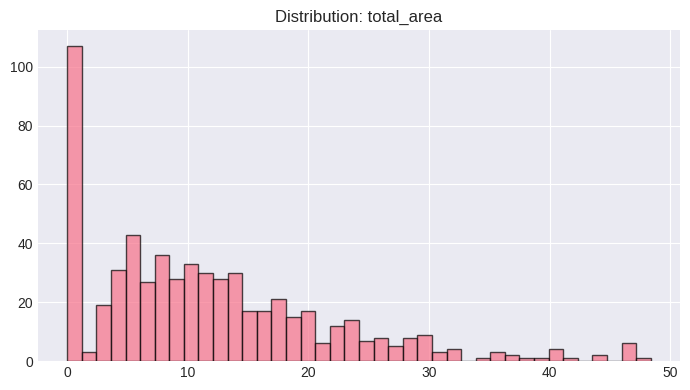

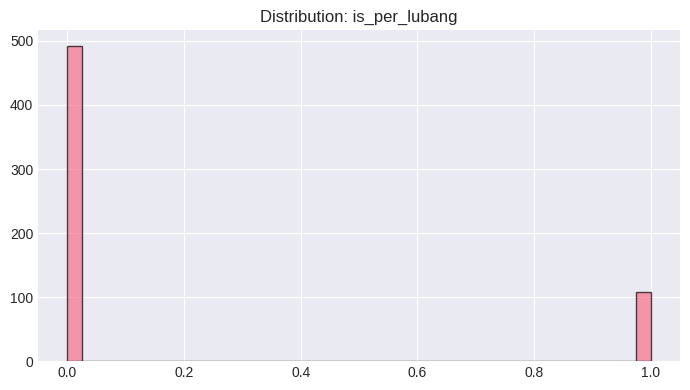

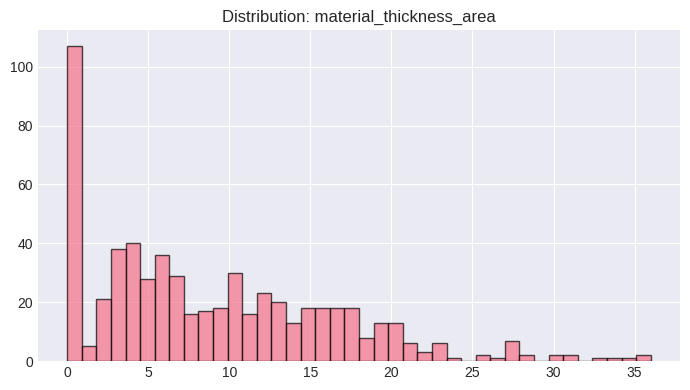

In [ ]:
print("="*80)
print("✅ POST-FEATURE-ENGINEERING VALIDATION")
print("="*80)

# Check newly created engineered cols existence
if 'selected_features' in globals():
    print("Selected engineered features:", selected_features)

    # Missing check after engineering
    miss = df_processed[selected_features].isna().mean().sort_values(ascending=False) * 100
    print("\nMissing % in engineered features:")
    display(miss.to_frame("missing_%"))

    # Correlation vs harga_final for selected engineered features
    corr = df_processed[selected_features + ['harga_final']].corr(numeric_only=True)['harga_final'].drop('harga_final') \
           .sort_values(ascending=False)
    print("\nCorrelation engineered features vs harga_final:")
    display(corr.to_frame("corr_harga_final"))

    # Simple distribution plots
    for f in selected_features[:6]:
        plt.figure(figsize=(7,4))
        plt.hist(df_processed[f].dropna(), bins=40, edgecolor='black', alpha=0.7)
        plt.title(f"Distribution: {f}")
        plt.tight_layout()
        plt.show()
else:
    print("selected_features belum ada. Jalankan dulu feature engineering section.")


## 5. Create Price Categories (Labels)

**Goal**: Membentuk target klasifikasi `kategori_harga` (Rendah/Sedang/Tinggi) dari `harga_final` secara **data-driven**.

**Approach**:
- Menggunakan clustering (KMeans) pada `log1p(harga_final)` untuk menemukan 3 kelompok harga natural.
- Threshold kelas (`thr1`, `thr2`) ditentukan dari midpoint antar centroid cluster → menghasilkan batas Rendah–Sedang–Tinggi.
- Distribusi kelas dievaluasi untuk mendeteksi potensi imbalance.
- Jika imbalance terdeteksi, disiapkan `rf_class_weight` untuk digunakan pada Random Forest.


### 5.1 Quantile Reference


In [ ]:
q = df_processed["harga_final"].quantile([0, 1/3, 2/3, 1]).to_dict()
print("Quantile reference (baseline only — NOT used for final labels):")
for k, v in q.items():
    print(f"  q={k:.2f}: Rp {v:,.0f}")


Quantile reference (baseline only — NOT used for final labels):
  q=0.00: Rp 1,200,000
  q=0.33: Rp 7,683,333
  q=0.67: Rp 13,050,000
  q=1.00: Rp 46,800,000


### 5.2 Data-driven Thresholds


In [ ]:
# Stabilize threshold: clipping 1%–99% (hanya untuk penentuan threshold)
p1, p99 = df_processed["harga_final"].quantile([0.01, 0.99])
x = np.log1p(df_processed["harga_final"].clip(p1, p99).values).reshape(-1, 1)

# cek kualitas clustering beberapa k
print("Silhouette Score (log1p clipped harga_final):")
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil = silhouette_score(x, km.fit_predict(x))
    print(f"  k={k}: {sil:.4f}")

# k=3 (Rendah/Sedang/Tinggi)
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k = km3.fit_predict(x)
centers = km3.cluster_centers_.flatten()

# Urutkan cluster dari murah -> mahal
order = np.argsort(centers)
c = centers[order]

# Threshold = midpoint antar centroid (di log-space), lalu balik ke Rupiah
thr1 = float(np.expm1((c[0] + c[1]) / 2))
thr2 = float(np.expm1((c[1] + c[2]) / 2))

if not (thr1 < thr2):
    raise ValueError(f"Threshold invalid: thr1={thr1}, thr2={thr2}. Check distribution.")

print("\n✅ Data-driven thresholds:")
print(f"  thr1 (Rendah–Sedang): Rp {thr1:,.0f}")
print(f"  thr2 (Sedang–Tinggi): Rp {thr2:,.0f}")


Silhouette Score (log1p clipped harga_final):
  k=2: 0.5634
  k=3: 0.5490
  k=4: 0.5210
  k=5: 0.5443

✅ Data-driven thresholds:
  thr1 (Rendah–Sedang): Rp 6,734,417
  thr2 (Sedang–Tinggi): Rp 14,155,163


### 5.2.1 Visualisasi Threshold pada Distribusi Harga


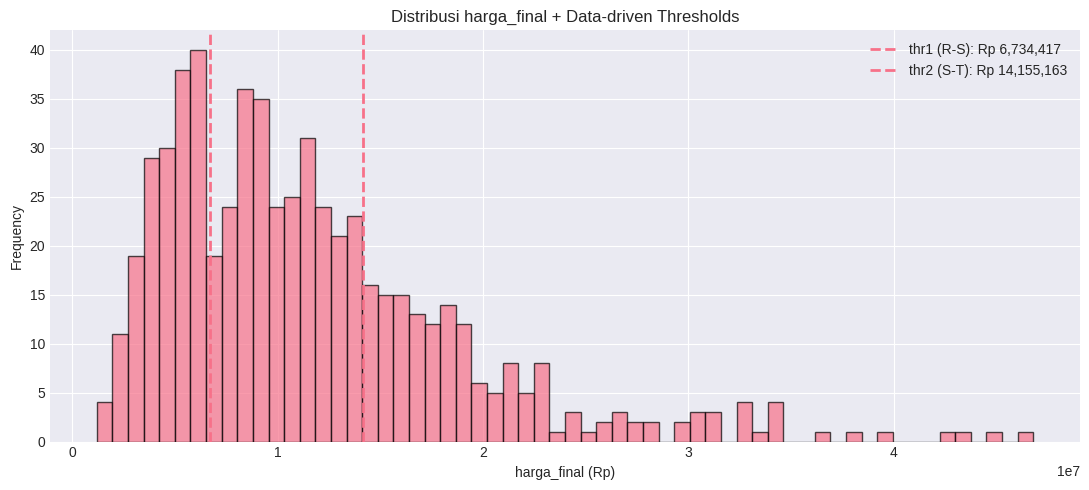

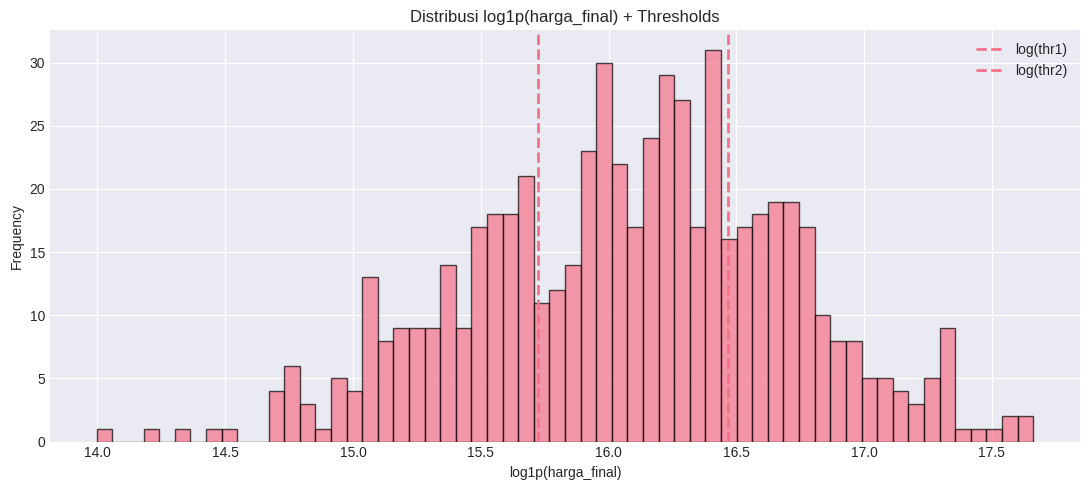

In [ ]:
harga = df_processed["harga_final"].values

# Histogram raw + threshold
plt.figure(figsize=(11,5))
plt.hist(harga, bins=60, edgecolor="black", alpha=0.7)
plt.axvline(thr1, linestyle="--", linewidth=2, label=f"thr1 (R-S): Rp {thr1:,.0f}")
plt.axvline(thr2, linestyle="--", linewidth=2, label=f"thr2 (S-T): Rp {thr2:,.0f}")
plt.title("Distribusi harga_final + Data-driven Thresholds")
plt.xlabel("harga_final (Rp)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Histogram log1p + threshold (lebih jelas kalau distribusi skew)
plt.figure(figsize=(11,5))
plt.hist(np.log1p(harga), bins=60, edgecolor="black", alpha=0.7)
plt.axvline(np.log1p(thr1), linestyle="--", linewidth=2, label="log(thr1)")
plt.axvline(np.log1p(thr2), linestyle="--", linewidth=2, label="log(thr2)")
plt.title("Distribusi log1p(harga_final) + Thresholds")
plt.xlabel("log1p(harga_final)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


### 5.3 Create Final Labels (Rendah/Sedang/Tinggi) + Distribusi Kelas


In [ ]:
df_processed["kategori_harga"] = pd.cut(
    df_processed["harga_final"],
    bins=[-np.inf, thr1, thr2, np.inf],
    labels=["Rendah", "Sedang", "Tinggi"]
)

kategori_counts = df_processed["kategori_harga"].value_counts().reindex(["Rendah","Sedang","Tinggi"], fill_value=0)
kategori_pct = (kategori_counts / len(df_processed) * 100).round(2)

print("✅ kategori_harga created (Data-driven).")
print("\n📊 Distribusi Kategori Harga:")
display(pd.DataFrame({"count": kategori_counts, "pct_%": kategori_pct}))


✅ kategori_harga created (Data-driven).

📊 Distribusi Kategori Harga:


,count,pct_%
kategori_harga,,
Rendah,173,28.83
Sedang,260,43.33
Tinggi,167,27.83


### 5.3.1 Statistik harga_final per Kategori (lebih deskriptif)


In [ ]:
stats = (
    df_processed.groupby("kategori_harga")["harga_final"]
    .agg(
        count="count",
        min="min",
        p25=lambda x: x.quantile(0.25),
        median="median",
        mean="mean",
        p75=lambda x: x.quantile(0.75),
        max="max",
        std="std"
    )
    .reindex(["Rendah","Sedang","Tinggi"])
)

stats_fmt = stats.copy()
for c in ["min","p25","median","mean","p75","max","std"]:
    stats_fmt[c] = stats_fmt[c].map(lambda v: f"Rp {v:,.0f}" if pd.notna(v) else v)

print("📌 Statistik harga_final per kategori:")
display(stats_fmt)


📌 Statistik harga_final per kategori:


,count,min,p25,median,mean,p75,max,std
kategori_harga,,,,,,,,
Rendah,173,"Rp 1,200,000","Rp 3,650,000","Rp 4,700,000","Rp 4,672,543","Rp 5,700,000","Rp 6,550,000","Rp 1,288,313"
Sedang,260,"Rp 6,750,000","Rp 8,550,000","Rp 10,200,000","Rp 10,250,577","Rp 11,862,500","Rp 13,900,000","Rp 2,030,251"
Tinggi,167,"Rp 14,300,000","Rp 16,125,000","Rp 18,450,000","Rp 20,936,527","Rp 23,025,000","Rp 46,800,000","Rp 6,838,070"


### 5.3.2 Visualisasi Distribusi Kelas (Bar + ECDF + Violin)


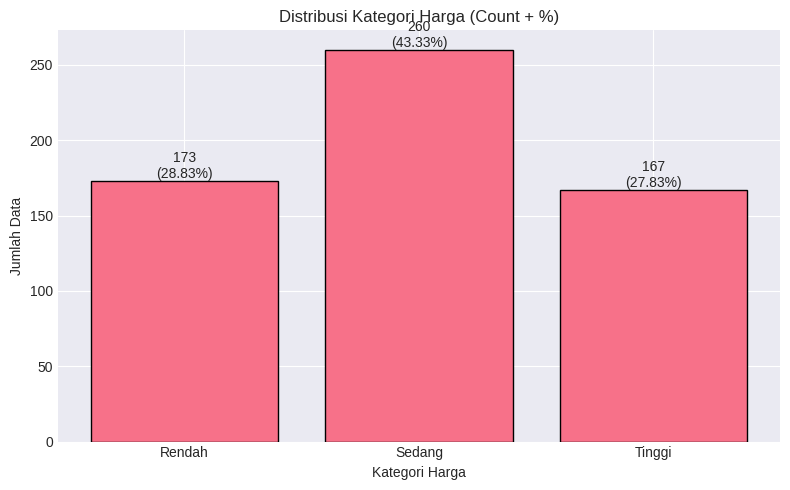

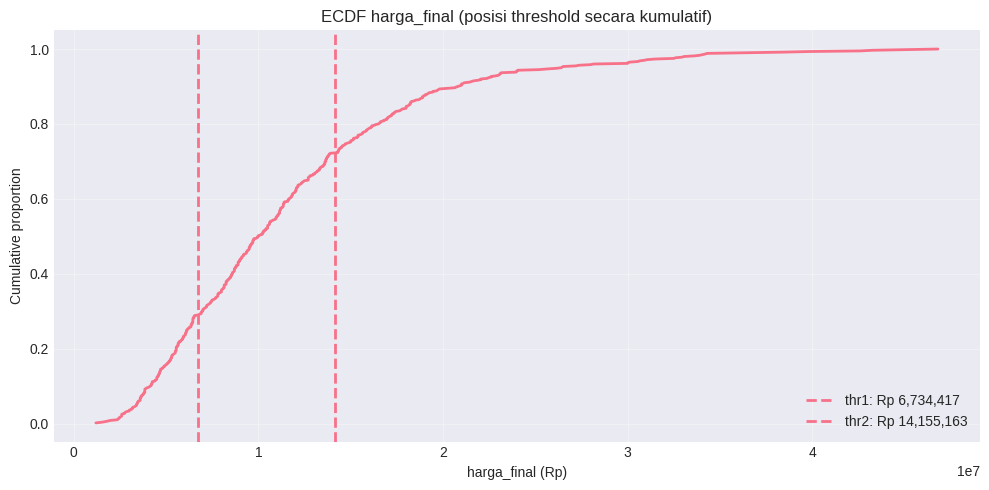

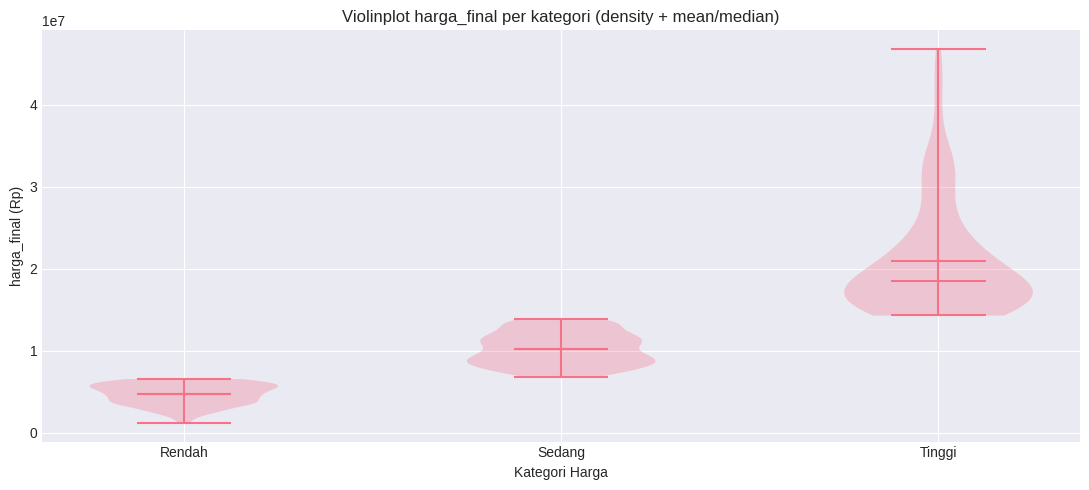

In [ ]:
labels = ["Rendah","Sedang","Tinggi"]
counts = kategori_counts
pct = kategori_pct

# Bar chart (count + %)
plt.figure(figsize=(8,5))
bars = plt.bar(labels, counts.values, edgecolor="black")
plt.title("Distribusi Kategori Harga (Count + %)")
plt.xlabel("Kategori Harga")
plt.ylabel("Jumlah Data")
for i, b in enumerate(bars):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(),
             f"{int(counts.iloc[i])}\n({pct.iloc[i]}%)",
             ha="center", va="bottom")
plt.tight_layout()
plt.show()

# ECDF (jelas untuk menunjukkan threshold memotong data di mana)
harga_sorted = np.sort(df_processed["harga_final"].values)
ecdf = np.arange(1, len(harga_sorted) + 1) / len(harga_sorted)

plt.figure(figsize=(10,5))
plt.plot(harga_sorted, ecdf, linewidth=2)
plt.axvline(thr1, linestyle="--", linewidth=2, label=f"thr1: Rp {thr1:,.0f}")
plt.axvline(thr2, linestyle="--", linewidth=2, label=f"thr2: Rp {thr2:,.0f}")
plt.title("ECDF harga_final (posisi threshold secara kumulatif)")
plt.xlabel("harga_final (Rp)")
plt.ylabel("Cumulative proportion")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Violin (lebih informatif daripada boxplot doang)
data_per_class = [
    df_processed[df_processed["kategori_harga"]=="Rendah"]["harga_final"].values,
    df_processed[df_processed["kategori_harga"]=="Sedang"]["harga_final"].values,
    df_processed[df_processed["kategori_harga"]=="Tinggi"]["harga_final"].values
]

plt.figure(figsize=(11,5))
plt.violinplot(data_per_class, showmeans=True, showmedians=True)
plt.xticks([1,2,3], labels)
plt.title("Violinplot harga_final per kategori (density + mean/median)")
plt.xlabel("Kategori Harga")
plt.ylabel("harga_final (Rp)")
plt.tight_layout()
plt.show()


### 5.4 Validasi Pola Label terhadap metode_hitung


📌 Proporsi kategori_harga per metode_hitung (row-normalized):


kategori_harga,Rendah,Sedang,Tinggi
metode_hitung,,,
PER-LUBANG,44.44,41.67,13.89
PER-M,28.57,38.39,33.04
PER-M2,24.47,45.26,30.26


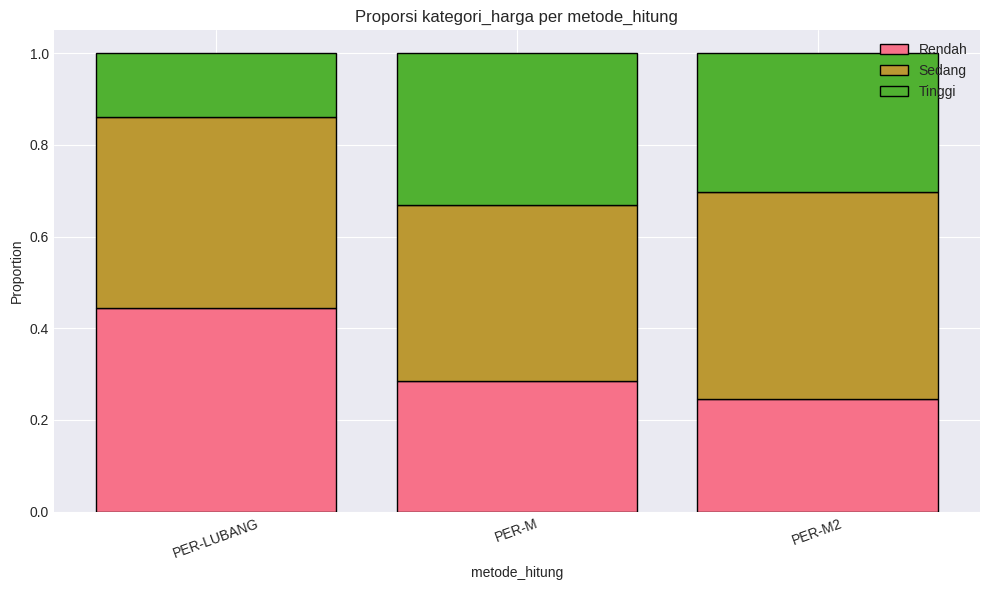

In [ ]:
if "metode_hitung" in df_processed.columns:
    ct = pd.crosstab(
        df_processed["metode_hitung"].astype(str).str.upper().str.strip(),
        df_processed["kategori_harga"],
        normalize="index"
    ).reindex(columns=["Rendah","Sedang","Tinggi"]).fillna(0)

    print("📌 Proporsi kategori_harga per metode_hitung (row-normalized):")
    display((ct*100).round(2))

    plt.figure(figsize=(10,6))
    bottom = np.zeros(len(ct))
    x = np.arange(len(ct.index))
    for col in ["Rendah","Sedang","Tinggi"]:
        vals = ct[col].values
        plt.bar(x, vals, bottom=bottom, edgecolor="black", label=col)
        bottom += vals

    plt.xticks(x, ct.index, rotation=20)
    plt.title("Proporsi kategori_harga per metode_hitung")
    plt.xlabel("metode_hitung")
    plt.ylabel("Proportion")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ kolom metode_hitung tidak ditemukan di df_processed.")


### 5.5 Check Imbalance & Set RandomForest class_weight
Jika imbalance terdeteksi, gunakan `class_weight='balanced'` agar model tidak bias ke kelas mayoritas.


In [ ]:
min_c = int(kategori_counts.min())
max_c = int(kategori_counts.max())
imbalance_ratio = (max_c / min_c) if min_c > 0 else float("inf")

print(f"📏 Imbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    rf_class_weight = "balanced"
    print("✅ rf_class_weight='balanced'")
else:
    rf_class_weight = None
    print("✅ rf_class_weight=None")

print("NOTE: Untuk cross-validation disarankan scoring='f1_macro' jika imbalance.")


📏 Imbalance ratio (max/min): 1.56
✅ rf_class_weight='balanced'
NOTE: Untuk cross-validation disarankan scoring='f1_macro' jika imbalance.


### 5.6 Save Thresholds & Price Ranges (Artifact)
Menyimpan threshold dan statistik kelas sebagai referensi (overwrite).


In [ ]:
price_ranges = {}
for kategori in ["Rendah","Sedang","Tinggi"]:
    subset = df_processed[df_processed["kategori_harga"] == kategori]["harga_final"]
    price_ranges[kategori] = {
        "min": int(subset.min()) if len(subset) else None,
        "max": int(subset.max()) if len(subset) else None,
        "mean": int(subset.mean()) if len(subset) else None,
        "median": int(subset.median()) if len(subset) else None,
        "count": int(len(subset))
    }

out = {
    "labeling_method": "KMeans clustering on log1p(harga_final) with 1%-99% clipping",
    "clip_p1": float(p1),
    "clip_p99": float(p99),
    "thr1_rendah_sedang": float(thr1),
    "thr2_sedang_tinggi": float(thr2),
    "class_counts": {k: int(v) for k, v in kategori_counts.items()},
    "imbalance_ratio": float(imbalance_ratio),
    "rf_class_weight": rf_class_weight,
    "price_ranges": price_ranges
}

print("="*90)
print("📌 LABELING SUMMARY (Data-driven)")
print("="*90)
print("Method       :", out["labeling_method"])
print(f"Clip range   : p1=Rp {out['clip_p1']:,.0f} | p99=Rp {out['clip_p99']:,.0f}")
print(f"Thresholds   : thr1=Rp {out['thr1_rendah_sedang']:,.0f} | thr2=Rp {out['thr2_sedang_tinggi']:,.0f}")
print("Class counts :", out["class_counts"])
print(f"Imbalance    : ratio={out['imbalance_ratio']:.2f} | rf_class_weight={out['rf_class_weight']}")
print("\nPrice ranges per class:")
for k in ["Rendah","Sedang","Tinggi"]:
    r = out["price_ranges"][k]
    print(f"- {k:<6} | count={r['count']:<4} | min=Rp {r['min']:,.0f} | median=Rp {r['median']:,.0f} | mean=Rp {r['mean']:,.0f} | max=Rp {r['max']:,.0f}")
print("="*90)

with open("price_ranges_classification.json", "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2)

print("✅ Saved: price_ranges_classification.json")


📌 LABELING SUMMARY (Data-driven)
Method       : KMeans clustering on log1p(harga_final) with 1%-99% clipping
Clip range   : p1=Rp 2,399,500 | p99=Rp 36,519,000
Thresholds   : thr1=Rp 6,734,417 | thr2=Rp 14,155,163
Class counts : {'Rendah': 173, 'Sedang': 260, 'Tinggi': 167}
Imbalance    : ratio=1.56 | rf_class_weight=balanced

Price ranges per class:
- Rendah | count=173  | min=Rp 1,200,000 | median=Rp 4,700,000 | mean=Rp 4,672,543 | max=Rp 6,550,000
- Sedang | count=260  | min=Rp 6,750,000 | median=Rp 10,200,000 | mean=Rp 10,250,576 | max=Rp 13,900,000
- Tinggi | count=167  | min=Rp 14,300,000 | median=Rp 18,450,000 | mean=Rp 20,936,526 | max=Rp 46,800,000
✅ Saved: price_ranges_classification.json


---
## 6. Save Price Ranges for Prediction Output


In [ ]:
# Simpan mapping range harga per kategori
price_ranges = {}
for kategori in ['Rendah', 'Sedang', 'Tinggi']:
    subset = df_processed[df_processed['kategori_harga'] == kategori]['harga_final']
    price_ranges[kategori] = {
        'min': int(subset.min()),
        'max': int(subset.max()),
        'mean': int(subset.mean()),
        'median': int(subset.median()),
        'count': int(len(subset))
    }

# Save to JSON (overwrite mode)
with open('price_ranges_classification.json', 'w', encoding='utf-8') as f:
    json.dump(price_ranges, f, indent=2)

print("✅ Price ranges saved to 'price_ranges_classification.json'")
print("\n📊 Price Ranges Summary:")
print(json.dumps(price_ranges, indent=2))


✅ Price ranges saved to 'price_ranges_classification.json'

📊 Price Ranges Summary:
{
  "Rendah": {
    "min": 1200000,
    "max": 6550000,
    "mean": 4672543,
    "median": 4700000,
    "count": 173
  },
  "Sedang": {
    "min": 6750000,
    "max": 13900000,
    "mean": 10250576,
    "median": 10200000,
    "count": 260
  },
  "Tinggi": {
    "min": 14300000,
    "max": 46800000,
    "mean": 20936526,
    "median": 18450000,
    "count": 167
  }
}


---
## 7. Prepare Data for Modeling


### 7.1 Split Features & Target


In [ ]:
X = df_processed[all_features].copy()
y = df_processed['kategori_harga'].astype(str).copy()

class_labels = ['Rendah', 'Sedang', 'Tinggi']

print("Target distribution:")
print(y.value_counts().reindex(class_labels))


Target distribution:
kategori_harga
Rendah    173
Sedang    260
Tinggi    167
Name: count, dtype: int64


### 7.2 Train-Test Split (Stratified)


In [ ]:
# Split data dengan stratify untuk mempertahankan proporsi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Penting untuk classification!
)

print(f"✅ Data split completed!")
print(f"   Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Cek distribusi kelas di train dan test
print("\n📊 Class Distribution:")
print("\nTraining set:")
train_dist = pd.Series(y_train).value_counts().reindex(class_labels, fill_value=0)
for label, count in train_dist.items():
    print(f"   {label}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nTest set:")
test_dist = pd.Series(y_test).value_counts().reindex(class_labels, fill_value=0)
for label, count in test_dist.items():
    print(f"   {label}: {count} ({count/len(y_test)*100:.1f}%)")


✅ Data split completed!
   Training set: 480 samples (80.0%)
   Test set: 120 samples (20.0%)

📊 Class Distribution:

Training set:
   Rendah: 138 (28.7%)
   Sedang: 208 (43.3%)
   Tinggi: 134 (27.9%)

Test set:
   Rendah: 35 (29.2%)
   Sedang: 52 (43.3%)
   Tinggi: 33 (27.5%)


---
## 8. Build Preprocessing Pipeline


In [ ]:
from sklearn.impute import SimpleImputer

# NUMERIC: missing -> 0 (aman kalau jumlah_lubang kosong/NaN), lalu scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# CATEGORICAL: missing -> most_frequent, kategori baru di-ignore (biar web tidak error)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("✅ Preprocessing pipeline created (with imputers)!")


✅ Preprocessing pipeline created (with imputers)!


---
## 9. Build & Train Classification Model


### 9.1 Random Forest Classifier (Single Model)


In [ ]:
# Build model pipeline (SINGLE MODEL - tidak pakai SMOTE)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight=rf_class_weight
    ))
])

print("🚀 Training Random Forest Classifier (Single Model)...")
print("   Strategy: metode_hitung sebagai categorical feature")
print("   → Model otomatis belajar context per metode!")
print()
model.fit(X_train, y_train)
print("✅ Model training completed!")


🚀 Training Random Forest Classifier (Single Model)...
   Strategy: metode_hitung sebagai categorical feature
   → Model otomatis belajar context per metode!

✅ Model training completed!


### 9.2 Cross-Validation


In [ ]:
# Stratified K-Fold Cross Validation
print("🔄 Performing 5-Fold Cross-Validation...\n")

cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

print(f"📊 Cross-Validation Accuracy Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\n📊 Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


🔄 Performing 5-Fold Cross-Validation...

📊 Cross-Validation Accuracy Scores:
   Fold 1: 0.8854
   Fold 2: 0.9062
   Fold 3: 0.9167
   Fold 4: 0.8229
   Fold 5: 0.8854

📊 Mean CV Accuracy: 0.8833 (+/- 0.0651)


---
## 10. Model Evaluation


### 10.1 Predictions


In [ ]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Prediction probabilities
y_train_proba = model.predict_proba(X_train)
y_test_proba = model.predict_proba(X_test)

print("✅ Predictions completed!")


✅ Predictions completed!


### 10.2 Classification Metrics


In [ ]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)

train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)

train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("="*80)
print("📊 MODEL EVALUATION RESULTS")
print("="*80)
print(f"\n{'Metric':<20} {'Training':<15} {'Testing':<15} {'Difference':<15}")
print("-" * 80)
print(f"{'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f} {abs(train_accuracy - test_accuracy):<15.4f}")
print(f"{'Precision':<20} {train_precision:<15.4f} {test_precision:<15.4f} {abs(train_precision - test_precision):<15.4f}")
print(f"{'Recall':<20} {train_recall:<15.4f} {test_recall:<15.4f} {abs(train_recall - test_recall):<15.4f}")
print(f"{'F1-Score':<20} {train_f1:<15.4f} {test_f1:<15.4f} {abs(train_f1 - test_f1):<15.4f}")
print("="*80)

# Overfitting check
overfit_margin = train_accuracy - test_accuracy
if overfit_margin > 0.1:
    print("\n⚠️ WARNING: Model mungkin overfitting (training-test gap > 10%)")
elif overfit_margin > 0.05:
    print("\n⚠️ CAUTION: Slight overfitting detected (training-test gap > 5%)")
else:
    print("\n✅ Model generalization looks good!")


📊 MODEL EVALUATION RESULTS

Metric               Training        Testing         Difference     
--------------------------------------------------------------------------------
Accuracy             0.9750          0.8917          0.0833         
Precision            0.9751          0.8917          0.0834         
Recall               0.9750          0.8917          0.0833         
F1-Score             0.9750          0.8914          0.0836         

⚠️ CAUTION: Slight overfitting detected (training-test gap > 5%)


### 10.3 Classification Report


In [ ]:
# Detailed classification report
print("\n📋 CLASSIFICATION REPORT (Test Set):\n")
print(classification_report(
    y_test, y_test_pred,
    labels=class_labels,
    target_names=class_labels,
    digits=4,
    zero_division=0
))



📋 CLASSIFICATION REPORT (Test Set):

              precision    recall  f1-score   support

      Rendah     0.8919    0.9429    0.9167        35
      Sedang     0.8824    0.8654    0.8738        52
      Tinggi     0.9062    0.8788    0.8923        33

    accuracy                         0.8917       120
   macro avg     0.8935    0.8957    0.8943       120
weighted avg     0.8917    0.8917    0.8914       120



### 10.4 Confusion Matrix


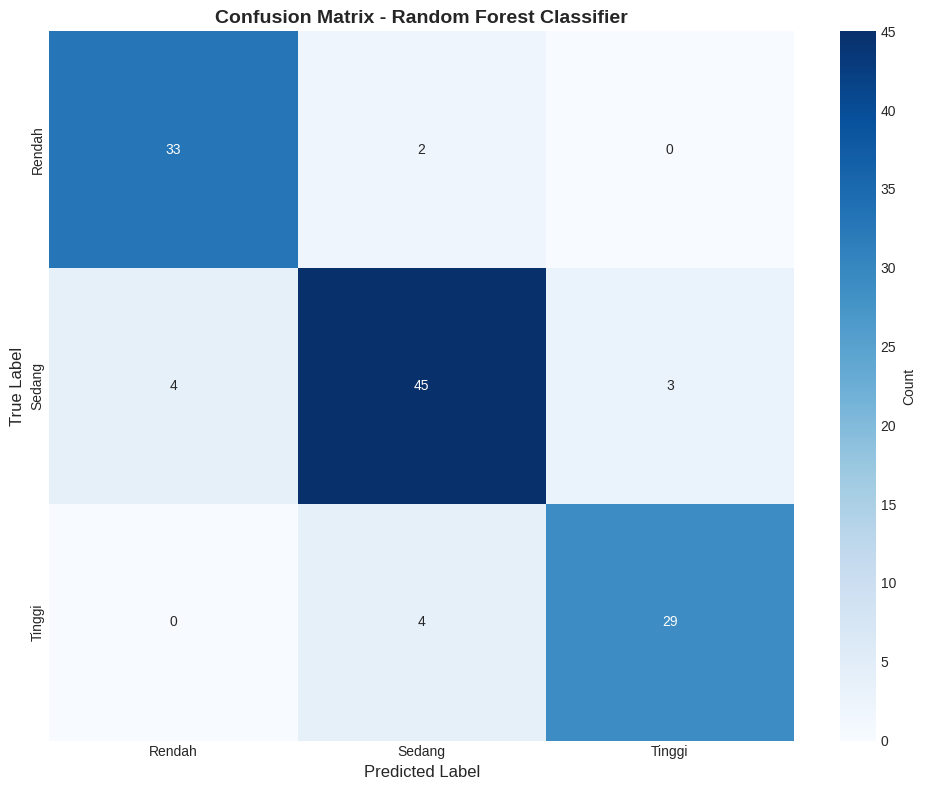


📊 Per-Class Accuracy:
   Rendah: 0.9429
   Sedang: 0.8654
   Tinggi: 0.8788


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=class_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\n📊 Per-Class Accuracy:")
for i, label in enumerate(class_labels):
    denom = cm[i, :].sum()
    class_accuracy = (cm[i, i] / denom) if denom else 0.0
    print(f"   {label}: {class_accuracy:.4f}")


### 10.5 Feature Importance



🎯 Top 20 Most Important Features:

                        feature  importance
               upah_tenaga_ahli    0.286745
                     total_area    0.173752
                         ukuran    0.104839
        material_thickness_area    0.097315
                   harga_per_m2    0.047600
          jenis_material_Hollow    0.042151
            finishing_Tanpa Cat    0.031782
                  jumlah_lubang    0.027738
                    jumlah_unit    0.022612
jenis_material_Hollow Stainless    0.020049
                    harga_per_m    0.012859
               harga_per_lubang    0.012766
      kerumitan_desain_Kompleks    0.012715
             ketebalan_material    0.011321
  jenis_material_Pipa Stainless    0.011264
                  produk_Kanopi    0.010797
                   produk_Pagar    0.009223
     kerumitan_desain_Sederhana    0.008208
      kerumitan_desain_Menengah    0.008188
         produk_Pintu Handerson    0.006797


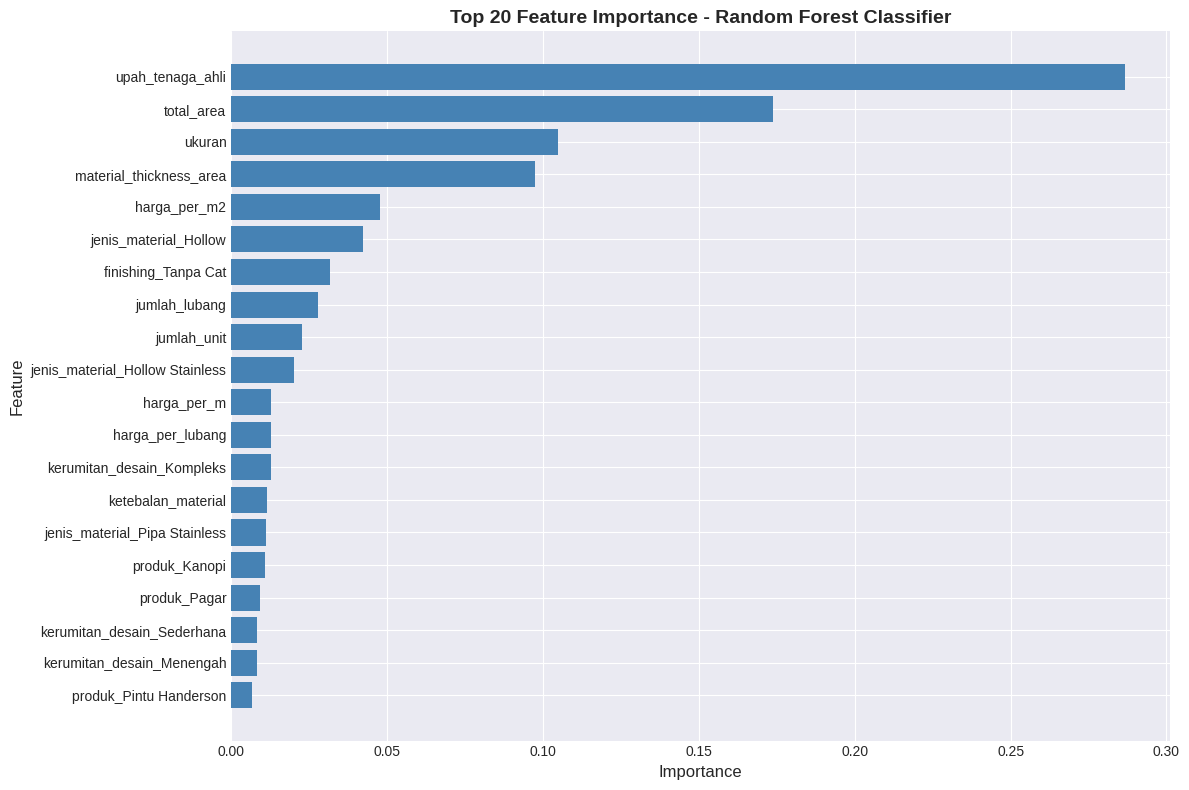


✅ Feature importances saved to 'feature_importances_classification.csv'


In [ ]:
# Get feature importance dari Random Forest
rf_classifier = model.named_steps['classifier']

# Get feature names after preprocessing
feature_names = (
    numerical_features +
    list(model.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_features))
)

# Feature importance
importances = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 20 features
top_20 = feature_importance_df.head(20)

print("\n🎯 Top 20 Most Important Features:\n")
print(top_20.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_20)), top_20['importance'], color='steelblue')
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Feature Importance - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save feature importance (overwrite)
feature_importance_df.to_csv('feature_importances_classification.csv', index=False)
print("\n✅ Feature importances saved to 'feature_importances_classification.csv'")


---
## 11. Save Model & Artifacts (Overwrite Mode)


In [ ]:
# Save trained model (overwrite)
model_filename = 'classification_model_pipeline.joblib'
joblib.dump(model, model_filename)
print(f"✅ Model saved to '{model_filename}'")

# Save evaluation metrics (overwrite)
metrics = {
    'train_accuracy': float(train_accuracy),
    'test_accuracy': float(test_accuracy),
    'train_precision': float(train_precision),
    'test_precision': float(test_precision),
    'train_recall': float(train_recall),
    'test_recall': float(test_recall),
    'train_f1': float(train_f1),
    'test_f1': float(test_f1),
    'cv_mean_accuracy': float(cv_scores.mean()) if 'cv_scores' in globals() else None,
    'cv_std_accuracy': float(cv_scores.std()) if 'cv_scores' in globals() else None,
    'total_features': len(all_features),
    'numerical_features': len(numerical_features),
    'categorical_features': len(categorical_features),
    'strategy': 'single_model_like_regression'
}

with open('metrics_classification.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)
print(f"✅ Metrics saved to 'metrics_classification.json'")

# Save feature list (overwrite)
feature_info = {
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'all_features': all_features,
    'class_labels': class_labels,
    'note': 'Target is STRING labels; model.predict returns Rendah/Sedang/Tinggi directly'
}

with open('feature_columns_classification.json', 'w', encoding='utf-8') as f:
    json.dump(feature_info, f, indent=2)
print(f"✅ Feature columns saved to 'feature_columns_classification.json'")

print("\n" + "="*80)
print("🎉 CLASSIFICATION MODEL SAVED SUCCESSFULLY!")
print("="*80)
print("\n📦 Saved Artifacts:")
print("   1. classification_model_pipeline.joblib (single model)")
print("   2. price_ranges_classification.json")
print("   3. metrics_classification.json")
print("   4. feature_columns_classification.json")
print("   5. feature_importances_classification.csv")
print("\n✅ Strategy: Single Model (seperti regression)")
print(f"✅ Test Accuracy: {test_accuracy:.4f}")
print(f"✅ Model otomatis handle semua metode hitung!")


✅ Model saved to 'classification_model_pipeline.joblib'
✅ Metrics saved to 'metrics_classification.json'
✅ Feature columns saved to 'feature_columns_classification.json'

🎉 CLASSIFICATION MODEL SAVED SUCCESSFULLY!

📦 Saved Artifacts:
   1. classification_model_pipeline.joblib (single model)
   2. price_ranges_classification.json
   3. metrics_classification.json
   4. feature_columns_classification.json
   5. feature_importances_classification.csv

✅ Strategy: Single Model (seperti regression)
✅ Test Accuracy: 0.8917
✅ Model otomatis handle semua metode hitung!


Coba


In [ ]:
import pandas as pd
import numpy as np
import joblib, json

# LOAD artifacts
model = joblib.load("classification_model_pipeline.joblib")
with open("feature_columns_classification.json", "r", encoding="utf-8") as f:
    info = json.load(f)

all_features = info["all_features"]
numerical_features = info["numerical_features"]
categorical_features = info["categorical_features"]
class_labels = info["class_labels"]

def _to_float(x, default=0.0):
    try:
        if x is None or (isinstance(x, str) and x.strip() == ""):
            return float(default)
        return float(x)
    except:
        return float(default)

def build_input_df(payload: dict) -> pd.DataFrame:
    # 1) isi default
    row = {c: payload.get(c, 0) for c in all_features}

    # 2) cast numeric
    for c in numerical_features:
        row[c] = _to_float(row.get(c, 0), 0.0)

    # 3) normalize categorical (strip + standar case untuk metode_hitung)
    for c in categorical_features:
        v = row.get(c, "")
        v = "" if v is None else str(v).strip()
        row[c] = v

    if "metode_hitung" in row:
        row["metode_hitung"] = row["metode_hitung"].upper()

    # 4) hitung engineered features kalau ada di all_features
    # (harus sama dengan training)
    if "total_area" in all_features:
        row["total_area"] = _to_float(row.get("ukuran", 0)) * _to_float(row.get("jumlah_unit", 0))
    if "total_lubang" in all_features:
        row["total_lubang"] = _to_float(row.get("jumlah_lubang", 0)) * _to_float(row.get("jumlah_unit", 0))
    if "is_per_m2" in all_features:
        row["is_per_m2"] = 1 if row.get("metode_hitung", "").upper() == "PER-M2" else 0
    if "is_per_lubang" in all_features:
        row["is_per_lubang"] = 1 if row.get("metode_hitung", "").upper() == "PER-LUBANG" else 0
    if "material_thickness_area" in all_features:
        row["material_thickness_area"] = _to_float(row.get("ketebalan_material", 0)) * _to_float(row.get("ukuran", 0))

    # 5) buat DF dengan urutan kolom yang bener
    return pd.DataFrame([row], columns=all_features)

def predict_payload(payload: dict):
    X_in = build_input_df(payload)
    pred = model.predict(X_in)[0]
    proba = model.predict_proba(X_in)[0]
    classes = list(model.named_steps["classifier"].classes_)
    proba_map = {cls: float(p) for cls, p in zip(classes, proba)}
    return pred, proba_map


In [ ]:
payload_16150000 = {
    "produk": "Teralis",
    "jenis_material": "Hollow Stainless",
    "ketebalan_material": 1.2,
    "ukuran": 0,                 # sesuai data kamu
    "jumlah_unit": 1,
    "jumlah_lubang": 20,
    "metode_hitung": "PER-LUBANG",
    "harga_per_m2": 0,
    "harga_per_m": 0,
    "harga_per_lubang": 800000,
    "upah_tenaga_ahli": 3000000,
    "finishing": "Tanpa Cat",
    "kerumitan_desain": "Kompleks",
}

pred, proba = predict_payload(payload_16150000)
print("Pred:", pred)
print("Proba:", proba)


Pred: Tinggi
Proba: {'Rendah': 0.01920799679879197, 'Sedang': 0.028735284406113767, 'Tinggi': 0.9520567187950942}


In [ ]:
# TEST: ambil 5 baris asli dari dataset, cek prediksi vs label
sample = df_processed.sample(5, random_state=42).copy()

X_s = sample[all_features]
y_true = sample['kategori_harga'].astype(str)

y_pred = model.predict(X_s)

print(sample[['produk','metode_hitung','harga_final','kategori_harga']])
print("\nPRED vs TRUE:")
for i in range(len(sample)):
    print(f"- true={y_true.iloc[i]} | pred={y_pred[i]}")


              produk metode_hitung  harga_final kategori_harga
110    Pintu Gerbang        PER-M2     12700000         Sedang
419          Railing         PER-M     27350000         Tinggi
565    Pintu Gerbang        PER-M2     10250000         Sedang
77           Railing         PER-M     43250000         Tinggi
181  Pintu Handerson        PER-M2      3400000         Rendah

PRED vs TRUE:
- true=Sedang | pred=Sedang
- true=Tinggi | pred=Tinggi
- true=Sedang | pred=Sedang
- true=Tinggi | pred=Tinggi
- true=Rendah | pred=Rendah


In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# Helper: bikin input inference aman (kosong -> NaN -> diimpute 0 oleh pipeline)
# =========================================================
def build_input_df_safe(payload: dict) -> pd.DataFrame:
    # 1) buat row lengkap sesuai all_features
    row = {c: payload.get(c, np.nan) for c in all_features}

    # 2) normalisasi kategori
    for c in categorical_features:
        v = row.get(c, "")
        row[c] = "" if v is None else str(v).strip()
    if "metode_hitung" in row and isinstance(row["metode_hitung"], str):
        row["metode_hitung"] = row["metode_hitung"].upper()

    # 3) convert numeric: "" / None -> NaN (biar imputer numeric bekerja)
    df_in = pd.DataFrame([row], columns=all_features)
    for c in numerical_features:
        df_in[c] = pd.to_numeric(df_in[c], errors="coerce")

    # 4) hitung engineered features kalau ada
    # (harus konsisten dengan training)
    if "total_area" in all_features:
        df_in["total_area"] = df_in["ukuran"] * df_in["jumlah_unit"]
    if "total_lubang" in all_features:
        df_in["total_lubang"] = df_in["jumlah_lubang"] * df_in["jumlah_unit"]
    if "is_per_m2" in all_features:
        df_in["is_per_m2"] = (df_in["metode_hitung"].astype(str).str.upper() == "PER-M2").astype(int)
    if "is_per_lubang" in all_features:
        df_in["is_per_lubang"] = (df_in["metode_hitung"].astype(str).str.upper() == "PER-LUBANG").astype(int)
    if "material_thickness_area" in all_features:
        df_in["material_thickness_area"] = df_in["ketebalan_material"] * df_in["ukuran"]

    return df_in[all_features]

def predict_one(payload: dict):
    X_in = build_input_df_safe(payload)
    pred = model.predict(X_in)[0]
    proba = model.predict_proba(X_in)[0]
    classes = list(model.named_steps["classifier"].classes_)
    proba_map = {cls: float(p) for cls, p in zip(classes, proba)}
    return pred, proba_map

# =========================================================
# TEST 1: Non PER-LUBANG harus "tidak keganggu" kalau lubang kosong
# =========================================================
payload_per_m2_ok = {
    "produk": "Pintu Handerson",
    "jenis_material": "Hollow",
    "ketebalan_material": 0.8,
    "ukuran": 4.73,
    "jumlah_unit": 1,
    "jumlah_lubang": 0,         # baseline
    "metode_hitung": "PER-M2",
    "harga_per_m2": 800000,
    "harga_per_m": 0,
    "harga_per_lubang": 0,
    "upah_tenaga_ahli": 473000,
    "finishing": "Cat Biasa",
    "kerumitan_desain": "Sederhana",
}

payload_per_m2_blank = payload_per_m2_ok.copy()
payload_per_m2_blank["jumlah_lubang"] = None  # simulasikan kosong

pred0, proba0 = predict_one(payload_per_m2_ok)
pred_blank, proba_blank = predict_one(payload_per_m2_blank)

print("="*80)
print("TEST 1 - PER-M2 (non-lubang): jumlah_lubang=0 vs jumlah_lubang kosong")
print("="*80)
print("Pred (0)     :", pred0, "| Proba:", proba0)
print("Pred (blank) :", pred_blank, "| Proba:", proba_blank)
print("✅ OK" if pred0 == pred_blank else "⚠️ WARNING: Prediksi berubah (cek preprocessing/imputer)")

# =========================================================
# TEST 2: PER-LUBANG kalau lubang kosong -> dianggap 0 -> prediksi bisa turun (ini wajar)
# =========================================================
payload_lubang_ok = {
    "produk": "Teralis",
    "jenis_material": "Hollow Stainless",
    "ketebalan_material": 1.2,
    "ukuran": 0,
    "jumlah_unit": 1,
    "jumlah_lubang": 20,
    "metode_hitung": "PER-LUBANG",
    "harga_per_m2": 0,
    "harga_per_m": 0,
    "harga_per_lubang": 800000,
    "upah_tenaga_ahli": 3000000,
    "finishing": "Tanpa Cat",
    "kerumitan_desain": "Kompleks",
}

payload_lubang_blank = payload_lubang_ok.copy()
payload_lubang_blank["jumlah_lubang"] = None  # simulasikan kosong

predL, probaL = predict_one(payload_lubang_ok)
predL_blank, probaL_blank = predict_one(payload_lubang_blank)

print("\n" + "="*80)
print("TEST 2 - PER-LUBANG (lubang penting): jumlah_lubang=20 vs kosong")
print("="*80)
print("Pred (20)    :", predL, "| Proba:", probaL)
print("Pred (blank) :", predL_blank, "| Proba:", probaL_blank)
print("Catatan: Kalau prediksi turun saat lubang kosong, itu NORMAL karena kosong dianggap 0 lubang.")

# =========================================================
# TEST 3: Random test dari data asli - cek non PER-LUBANG: blank vs 0 harus identik
# =========================================================
print("\n" + "="*80)
print("TEST 3 - Random rows (non PER-LUBANG): blank vs 0 harus sama")
print("="*80)

# Ambil baris non PER-LUBANG dari df_processed
df_non_lubang = df_processed[df_processed["metode_hitung"].astype(str).str.upper() != "PER-LUBANG"]
sample = df_non_lubang.sample(min(10, len(df_non_lubang)), random_state=42)

changed = 0
for idx, r in sample.iterrows():
    # payload dasar dari row
    payload = {c: r[c] for c in all_features if c in r.index}
    # pastikan kategori string rapi
    payload["metode_hitung"] = str(r["metode_hitung"]).upper()

    # versi 0 dan versi kosong
    payload0 = payload.copy()
    payload0["jumlah_lubang"] = 0

    payloadBlank = payload.copy()
    payloadBlank["jumlah_lubang"] = None

    p0, _ = predict_one(payload0)
    pb, _ = predict_one(payloadBlank)

    if p0 != pb:
        changed += 1
        print(f"⚠️ idx={idx} pred berubah: 0->{p0}, blank->{pb}")

if changed == 0:
    print("✅ Semua sample non PER-LUBANG: prediksi blank == prediksi 0 (AMAN)")
else:
    print(f"⚠️ Ada {changed} sample berubah. Ini indikasi preprocessing/imputer belum aktif untuk numeric.")

print("\nDONE.")


TEST 1 - PER-M2 (non-lubang): jumlah_lubang=0 vs jumlah_lubang kosong
Pred (0)     : Rendah | Proba: {'Rendah': 0.9911675485124957, 'Sedang': 0.00883245148750434, 'Tinggi': 0.0}
Pred (blank) : Rendah | Proba: {'Rendah': 0.9911675485124957, 'Sedang': 0.00883245148750434, 'Tinggi': 0.0}
✅ OK

TEST 2 - PER-LUBANG (lubang penting): jumlah_lubang=20 vs kosong
Pred (20)    : Tinggi | Proba: {'Rendah': 0.01920799679879197, 'Sedang': 0.028735284406113767, 'Tinggi': 0.9520567187950942}
Pred (blank) : Tinggi | Proba: {'Rendah': 0.12672076931143583, 'Sedang': 0.28322233951176784, 'Tinggi': 0.5900568911767963}
Catatan: Kalau prediksi turun saat lubang kosong, itu NORMAL karena kosong dianggap 0 lubang.

TEST 3 - Random rows (non PER-LUBANG): blank vs 0 harus sama
✅ Semua sample non PER-LUBANG: prediksi blank == prediksi 0 (AMAN)

DONE.
